# Restaurant Profitability & Loss Analysis

### A Data-Driven Analysis of Revenue, Orders, Channels & Restaurant Performance

## Business Objective

This project analyzes restaurant-level business performance to identify the factors associated with profitability and financial losses.

The analysis focuses on:

- Revenue and order performance
- Net profit and profit margin
- Channel-level profitability
- Business-segment performance
- Cuisine-level profitability
- Restaurant-level performance
- Loss-making restaurants
- Profit per order and revenue per order
- Comparison between profitable and loss-making restaurants

## Key Business Questions

1. Which channels generate the highest revenue and profit?
2. Which business segments are most profitable?
3. Which cuisines experience the largest losses?
4. Which restaurants are generating the highest losses?
5. How does profit per order differ between profitable and loss-making restaurants?
6. Does higher revenue necessarily result in higher profitability?
7. Which areas should management investigate to improve profitability?

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

## Key KPIs

- Revenue
- Orders
- Net Profit
- Profit Margin
- Profit Per Order
- Revenue Per Order

In [306]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


In [307]:
file_path = "../data/SkyCity Auckland Restaurants & Bars.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (1696, 30)


In [308]:
df.head()


,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders,UberEatsRevenue,DoorDashRevenue,SelfDeliveryRevenue,COGSRate,OPEXRate,CommissionRate,DeliveryRadiusKM,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
0,Burgers,25731,Urban Burgers House,Cafe,North Shore,1.03,43.97,668,197,8662.09,212,118,141,9321.64,5188.46,6199.77,0.208741,0.366172,0.28,11,3.25,458.25,3682.14,1352.45,752.78,2177.19,0.42,0.45,0.25,0.3
1,Burgers,25123,Urban Burgers Diner,QSR,South Auckland,1.05,40.45,1388,259,10476.55,508,282,339,20548.60,11406.90,13712.55,0.248217,0.407613,0.28,16,4.72,1600.08,3605.72,1318.61,731.99,3119.38,0.23,0.45,0.25,0.3
2,Burgers,25177,King Burgers Eatery,Cafe,West Auckland,1.04,40.03,1717,524,20975.72,537,298,358,21496.11,11928.94,14330.74,0.219688,0.407932,0.30,11,3.25,1163.50,7810.95,1555.90,863.42,4172.99,0.44,0.45,0.25,0.3
3,Burgers,25540,Classic Burgers Tavern,QSR,North Shore,1.03,36.28,1083,216,7836.48,390,217,260,14149.20,7872.76,9432.80,0.237291,0.437815,0.33,3,0.89,231.40,2546.02,-72.25,-40.20,2833.26,0.25,0.45,0.25,0.3
4,Burgers,25258,Lucky Burgers Bistro,Cafe,South Auckland,1.05,34.34,1230,261,8962.74,436,242,291,14972.24,8310.28,9992.94,0.221438,0.433457,0.33,9,2.66,774.06,3093.09,226.17,125.53,2674.56,0.27,0.45,0.25,0.3


In [309]:
df.tail()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders,UberEatsRevenue,DoorDashRevenue,SelfDeliveryRevenue,COGSRate,OPEXRate,CommissionRate,DeliveryRadiusKM,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
1691,Thai,26412,Lotus Bistro,Ghost Kitchen,North Shore,1.03,45.81,487,31,1420.11,228,137,91,10444.68,6275.97,4168.71,0.256343,0.218022,0.30,17,5.02,456.82,746.46,2356.69,1416.08,1734.40,0.07,0.5,0.3,0.2
1692,Thai,26275,Dragon Bistro,Ghost Kitchen,North Shore,1.03,44.20,956,62,2740.40,447,268,179,19757.40,11845.60,7911.80,0.288360,0.223346,0.30,17,5.02,898.58,1338.12,3720.20,2230.45,2964.70,0.07,0.5,0.3,0.2
1693,Thai,26454,Dragon Corner,QSR,South Auckland,1.05,44.72,758,62,2772.64,348,209,139,15562.56,9346.48,6216.08,0.240116,0.410384,0.32,5,1.48,205.72,969.04,459.09,275.72,1966.80,0.09,0.5,0.3,0.2
1694,Thai,25699,Golden Corner,Cafe,North Shore,1.03,36.98,1084,124,4585.52,480,288,192,17750.40,10650.24,7100.16,0.274149,0.380041,0.28,5,1.48,284.16,1585.72,1168.16,700.90,2171.15,0.13,0.5,0.3,0.2
1695,Thai,26388,Lotus Grill,Full-service,West Auckland,1.04,33.91,1284,186,6307.26,549,329,220,18616.59,11156.39,7460.20,0.362044,0.524470,0.28,15,4.43,974.60,715.79,-3099.92,-1857.69,-127.97,0.17,0.5,0.3,0.2


In [310]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CuisineType            1696 non-null   str    
 1   RestaurantID           1696 non-null   int64  
 2   RestaurantName         1696 non-null   str    
 3   Segment                1696 non-null   str    
 4   Subregion              1696 non-null   str    
 5   GrowthFactor           1696 non-null   float64
 6   AOV                    1696 non-null   float64
 7   MonthlyOrders          1696 non-null   int64  
 8   InStoreOrders          1696 non-null   int64  
 9   InStoreRevenue         1696 non-null   float64
 10  UberEatsOrders         1696 non-null   int64  
 11  DoorDashOrders         1696 non-null   int64  
 12  SelfDeliveryOrders     1696 non-null   int64  
 13  UberEatsRevenue        1696 non-null   float64
 14  DoorDashRevenue        1696 non-null   float64
 15  SelfDeliveryRev

In [311]:
print("Number of columns:", len(df.columns))

for i, col in enumerate(df.columns, start=1):
    print(i, "->", col)

Number of columns: 30
1 -> CuisineType
2 -> RestaurantID
3 -> RestaurantName
4 -> Segment
5 -> Subregion
6 -> GrowthFactor
7 -> AOV
8 -> MonthlyOrders
9 -> InStoreOrders
10 -> InStoreRevenue
11 -> UberEatsOrders
12 -> DoorDashOrders
13 -> SelfDeliveryOrders
14 -> UberEatsRevenue
15 -> DoorDashRevenue
16 -> SelfDeliveryRevenue
17 -> COGSRate
18 -> OPEXRate
19 -> CommissionRate
20 -> DeliveryRadiusKM
21 -> DeliveryCostPerOrder
22 -> SD_DeliveryTotalCost
23 -> InStoreNetProfit
24 -> UberEatsNetProfit
25 -> DoorDashNetProfit
26 -> SelfDeliveryNetProfit
27 -> InStoreShare
28 -> UE_share
29 -> DD_share
30 -> SD_share


In [312]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing = missing.sort_values(
    by="Missing_Count",
    ascending=False
)

missing

,Missing_Count,Missing_Percentage
CuisineType,0,0.0
RestaurantID,0,0.0
RestaurantName,0,0.0
Segment,0,0.0
Subregion,0,0.0
GrowthFactor,0,0.0
AOV,0,0.0
MonthlyOrders,0,0.0
InStoreOrders,0,0.0
InStoreRevenue,0,0.0


In [313]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


In [314]:
print("Duplicate RestaurantIDs:", df["RestaurantID"].duplicated().sum())

Duplicate RestaurantIDs: 0


In [315]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CuisineType,1696,8,Burgers,375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestaurantID,1696.0,NaN,NaN,NaN,25848.5,489.737345,25001.0,25424.75,25848.5,26272.25,26696.0
RestaurantName,1696,256,Lotus Eatery,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,1696,4,QSR,543,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subregion,1696,4,West Auckland,462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GrowthFactor,1696.0,NaN,NaN,NaN,1.028255,0.0227,0.99,1.03,1.04,1.05,1.05
AOV,1696.0,NaN,NaN,NaN,38.516887,4.459408,29.79,34.7875,38.34,42.495,47.23
MonthlyOrders,1696.0,NaN,NaN,NaN,1190.527123,422.334848,441.0,827.0,1182.0,1525.0,2337.0
InStoreOrders,1696.0,NaN,NaN,NaN,218.980542,149.758619,13.0,101.0,178.0,307.0,819.0
InStoreRevenue,1696.0,NaN,NaN,NaN,8422.39273,5851.233352,412.36,3904.3425,6791.43,11550.755,35356.23


In [316]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RestaurantID,1696.0,25848.500000,489.737345,25001.000000,25424.750000,25848.500000,26272.250000,26696.000000
GrowthFactor,1696.0,1.028255,0.022700,0.990000,1.030000,1.040000,1.050000,1.050000
AOV,1696.0,38.516887,4.459408,29.790000,34.787500,38.340000,42.495000,47.230000
MonthlyOrders,1696.0,1190.527123,422.334848,441.000000,827.000000,1182.000000,1525.000000,2337.000000
InStoreOrders,1696.0,218.980542,149.758619,13.000000,101.000000,178.000000,307.000000,819.000000
InStoreRevenue,1696.0,8422.392730,5851.233352,412.360000,3904.342500,6791.430000,11550.755000,35356.230000
UberEatsOrders,1696.0,471.906250,171.781981,142.000000,331.000000,456.000000,602.000000,937.000000
DoorDashOrders,1696.0,257.155071,92.605301,81.000000,179.750000,249.000000,326.250000,466.000000
SelfDeliveryOrders,1696.0,242.485259,129.950736,60.000000,146.000000,212.000000,306.250000,702.000000
UberEatsRevenue,1696.0,18170.030360,6959.241673,5050.950000,12524.745000,17548.980000,23016.000000,43038.960000


In [317]:
quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Count": df.isnull().sum().values,
    "Missing_Percentage": df.isnull().mean().values * 100,
    "Unique_Values": df.nunique().values
})

quality_report

,Column,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
0,CuisineType,str,0,0.0,8
1,RestaurantID,int64,0,0.0,1696
2,RestaurantName,str,0,0.0,256
3,Segment,str,0,0.0,4
4,Subregion,str,0,0.0,4
5,GrowthFactor,float64,0,0.0,4
6,AOV,float64,0,0.0,1064
7,MonthlyOrders,int64,0,0.0,1024
8,InStoreOrders,int64,0,0.0,515
9,InStoreRevenue,float64,0,0.0,1690


In [318]:
df["CalculatedTotalOrders"] = (
    df["InStoreOrders"]
    + df["UberEatsOrders"]
    + df["DoorDashOrders"]
    + df["SelfDeliveryOrders"]
)

df["OrderDifference"] = (
    df["MonthlyOrders"] - df["CalculatedTotalOrders"]
)

print("Rows where orders do not reconcile:",
      (df["OrderDifference"] != 0).sum())

Rows where orders do not reconcile: 0


In [319]:
df["ExpectedInStoreRevenue"] = df["AOV"] * df["InStoreOrders"]

df["ExpectedUberEatsRevenue"] = df["AOV"] * df["UberEatsOrders"]

df["ExpectedDoorDashRevenue"] = df["AOV"] * df["DoorDashOrders"]

df["ExpectedSelfDeliveryRevenue"] = df["AOV"] * df["SelfDeliveryOrders"]

In [320]:
df["InStoreRevenueDiff"] = (
    df["InStoreRevenue"] - df["ExpectedInStoreRevenue"]
)

df["UberEatsRevenueDiff"] = (
    df["UberEatsRevenue"] - df["ExpectedUberEatsRevenue"]
)

df["DoorDashRevenueDiff"] = (
    df["DoorDashRevenue"] - df["ExpectedDoorDashRevenue"]
)

df["SelfDeliveryRevenueDiff"] = (
    df["SelfDeliveryRevenue"] - df["ExpectedSelfDeliveryRevenue"]
)

In [321]:
print(
    "In-Store revenue mismatches:",
    (abs(df["InStoreRevenueDiff"]) > 0.01).sum()
)

print(
    "Uber Eats revenue mismatches:",
    (abs(df["UberEatsRevenueDiff"]) > 0.01).sum()
)

print(
    "DoorDash revenue mismatches:",
    (abs(df["DoorDashRevenueDiff"]) > 0.01).sum()
)

print(
    "Self-Delivery revenue mismatches:",
    (abs(df["SelfDeliveryRevenueDiff"]) > 0.01).sum()
)

In-Store revenue mismatches: 0
Uber Eats revenue mismatches: 0
DoorDash revenue mismatches: 0
Self-Delivery revenue mismatches: 0


In [322]:
df["ExpectedInStoreProfit"] = (
    df["InStoreRevenue"]
    * (1 - df["COGSRate"] - df["OPEXRate"])
)

df["InStoreProfitDiff"] = (
    df["InStoreNetProfit"]
    - df["ExpectedInStoreProfit"]
)

print(
    "In-Store profit mismatches:",
    (abs(df["InStoreProfitDiff"]) > 0.01).sum()
)

In-Store profit mismatches: 0


In [323]:
df["ExpectedUberEatsProfit"] = (
    df["UberEatsRevenue"]
    * (
        1
        - df["COGSRate"]
        - df["OPEXRate"]
        - df["CommissionRate"]
    )
)

df["UberEatsProfitDiff"] = (
    df["UberEatsNetProfit"]
    - df["ExpectedUberEatsProfit"]
)

print(
    "Uber Eats profit mismatches:",
    (abs(df["UberEatsProfitDiff"]) > 0.01).sum()
)

Uber Eats profit mismatches: 0


In [324]:
df["ExpectedDoorDashProfit"] = (
    df["DoorDashRevenue"]
    * (
        1
        - df["COGSRate"]
        - df["OPEXRate"]
        - df["CommissionRate"]
    )
)

df["DoorDashProfitDiff"] = (
    df["DoorDashNetProfit"]
    - df["ExpectedDoorDashProfit"]
)

print(
    "DoorDash profit mismatches:",
    (abs(df["DoorDashProfitDiff"]) > 0.01).sum()
)

DoorDash profit mismatches: 0


In [325]:
df["ExpectedSDDeliveryCost"] = (
    df["SelfDeliveryOrders"]
    * df["DeliveryCostPerOrder"]
)

df["SDDeliveryCostDiff"] = (
    df["SD_DeliveryTotalCost"]
    - df["ExpectedSDDeliveryCost"]
)

print(
    "Self-delivery cost mismatches:",
    (abs(df["SDDeliveryCostDiff"]) > 0.01).sum()
)

Self-delivery cost mismatches: 0


In [326]:
df["ExpectedSelfDeliveryProfit"] = (
    df["SelfDeliveryRevenue"]
    * (1 - df["COGSRate"] - df["OPEXRate"])
    - df["SD_DeliveryTotalCost"]
)

df["SelfDeliveryProfitDiff"] = (
    df["SelfDeliveryNetProfit"]
    - df["ExpectedSelfDeliveryProfit"]
)

print(
    "Self-delivery profit mismatches:",
    (abs(df["SelfDeliveryProfitDiff"]) > 0.01).sum()
)

Self-delivery profit mismatches: 0


In [327]:
df["TotalDeliveryOrders"] = (
    df["UberEatsOrders"]
    + df["DoorDashOrders"]
    + df["SelfDeliveryOrders"]
)

df["CalculatedInStoreShare"] = (
    df["InStoreOrders"] / df["MonthlyOrders"]
)

df["CalculatedUEShare"] = (
    df["UberEatsOrders"] / df["TotalDeliveryOrders"]
)

df["CalculatedDDShare"] = (
    df["DoorDashOrders"] / df["TotalDeliveryOrders"]
)

df["CalculatedSDShare"] = (
    df["SelfDeliveryOrders"] / df["TotalDeliveryOrders"]
)

In [328]:
print(
    "In-Store share mismatches:",
    (
        abs(df["InStoreShare"] - df["CalculatedInStoreShare"]) > 0.001
    ).sum()
)

print(
    "Uber Eats share mismatches:",
    (
        abs(df["UE_share"] - df["CalculatedUEShare"]) > 0.001
    ).sum()
)

print(
    "DoorDash share mismatches:",
    (
        abs(df["DD_share"] - df["CalculatedDDShare"]) > 0.001
    ).sum()
)

print(
    "Self-delivery share mismatches:",
    (
        abs(df["SD_share"] - df["CalculatedSDShare"]) > 0.001
    ).sum()
)

In-Store share mismatches: 1696
Uber Eats share mismatches: 21
DoorDash share mismatches: 10
Self-delivery share mismatches: 6


Profit Calculation Validation

The provided channel-level net profit calculations are validated against revenue, COGS rate, OPEX rate, commission rate, and self-delivery logistics cost.

In [329]:
analysis_df["ExpectedInStoreProfit"] = (
    analysis_df["InStoreRevenue"]
    * (
        1
        - analysis_df["COGSRate"]
        - analysis_df["OPEXRate"]
    )
)

analysis_df["InStoreProfitDifference"] = (
    analysis_df["InStoreNetProfit"]
    - analysis_df["ExpectedInStoreProfit"]
)

print(
    "In-Store profit mismatches:",
    (abs(analysis_df["InStoreProfitDifference"]) > 0.01).sum()
)

In-Store profit mismatches: 0


In [330]:
analysis_df["ExpectedUberEatsProfit"] = (
    analysis_df["UberEatsRevenue"]
    * (
        1
        - analysis_df["COGSRate"]
        - analysis_df["OPEXRate"]
        - analysis_df["CommissionRate"]
    )
)

analysis_df["UberEatsProfitDifference"] = (
    analysis_df["UberEatsNetProfit"]
    - analysis_df["ExpectedUberEatsProfit"]
)

print(
    "Uber Eats profit mismatches:",
    (abs(analysis_df["UberEatsProfitDifference"]) > 0.01).sum()
)

Uber Eats profit mismatches: 0


In [331]:
analysis_df["ExpectedDoorDashProfit"] = (
    analysis_df["DoorDashRevenue"]
    * (
        1
        - analysis_df["COGSRate"]
        - analysis_df["OPEXRate"]
        - analysis_df["CommissionRate"]
    )
)

analysis_df["DoorDashProfitDifference"] = (
    analysis_df["DoorDashNetProfit"]
    - analysis_df["ExpectedDoorDashProfit"]
)

print(
    "DoorDash profit mismatches:",
    (abs(analysis_df["DoorDashProfitDifference"]) > 0.01).sum()
)

DoorDash profit mismatches: 0


In [332]:
analysis_df["ExpectedSelfDeliveryProfit"] = (
    analysis_df["SelfDeliveryRevenue"]
    * (
        1
        - analysis_df["COGSRate"]
        - analysis_df["OPEXRate"]
    )
    - analysis_df["SD_DeliveryTotalCost"]
)

analysis_df["SelfDeliveryProfitDifference"] = (
    analysis_df["SelfDeliveryNetProfit"]
    - analysis_df["ExpectedSelfDeliveryProfit"]
)

print(
    "Self-Delivery profit mismatches:",
    (abs(analysis_df["SelfDeliveryProfitDifference"]) > 0.01).sum()
)

Self-Delivery profit mismatches: 0


In [333]:
analysis_df["ExpectedProfitMargin"] = (
    analysis_df["TotalNetProfit"] /
    analysis_df["TotalRevenue"]
)

analysis_df["ExpectedProfitPerOrder"] = (
    analysis_df["TotalNetProfit"] /
    analysis_df["MonthlyOrders"]
)

print(
    "Profit margin mismatches:",
    (
        abs(
            analysis_df["OverallProfitMargin"]
            - analysis_df["ExpectedProfitMargin"]
        ) > 0.0001
    ).sum()
)

print(
    "Profit per order mismatches:",
    (
        abs(
            analysis_df["NetProfitPerOrder"]
            - analysis_df["ExpectedProfitPerOrder"]
        ) > 0.01
    ).sum()
)

Profit margin mismatches: 0
Profit per order mismatches: 0


In [334]:
# Detect extreme profit margin values using the IQR method

Q1 = analysis_df["OverallProfitMargin"].quantile(0.25)
Q3 = analysis_df["OverallProfitMargin"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

analysis_df["MarginOutlier"] = (
    (analysis_df["OverallProfitMargin"] < lower_bound) |
    (analysis_df["OverallProfitMargin"] > upper_bound)
)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nNumber of margin outliers:",
      analysis_df["MarginOutlier"].sum())

print("Number of negative-margin restaurants:",
      (analysis_df["OverallProfitMargin"] < 0).sum())

Q1: 0.010079672002049345
Q3: 0.18651072932353444
IQR: 0.1764310573214851
Lower Bound: -0.2545669139801783
Upper Bound: 0.4511573153057621

Number of margin outliers: 0
Number of negative-margin restaurants: 408


In [335]:
# Show the 10 lowest profit margins

analysis_df[
    ["RestaurantName", "CuisineType", "Segment",
     "OverallProfitMargin", "NetProfitPerOrder"]
].sort_values(
    "OverallProfitMargin"
).head(10)

,RestaurantName,CuisineType,Segment,OverallProfitMargin,NetProfitPerOrder
1284,Ottoman Bistro,Kebabs/Mediterranean,Full-service,-0.176629,-6.591778
1207,Mediterranean Grill,Kebabs/Mediterranean,Full-service,-0.165376,-5.819571
1189,Sakura Kitchen,Japanese,Full-service,-0.148899,-5.451207
427,Top Chicken Dishes Tavern,Chicken Dishes,Full-service,-0.145946,-5.262809
1104,Lotus Grill,Japanese,Full-service,-0.141657,-4.843248
1247,Greek House,Kebabs/Mediterranean,Full-service,-0.141476,-4.753583
1315,Souvlaki Tavern,Kebabs/Mediterranean,Full-service,-0.140358,-5.316768
388,Urban Chicken Dishes Bistro,Chicken Dishes,Full-service,-0.139555,-4.349914
1083,Golden Bistro,Japanese,Full-service,-0.139319,-4.389932
1084,Lotus Grill,Japanese,Full-service,-0.137135,-5.381193


In [336]:
# Show the 10 highest profit margins

analysis_df[
    ["RestaurantName", "CuisineType", "Segment",
     "OverallProfitMargin", "NetProfitPerOrder"]
].sort_values(
    "OverallProfitMargin",
    ascending=False
).head(10)

,RestaurantName,CuisineType,Segment,OverallProfitMargin,NetProfitPerOrder
1403,Classic Pizza House,Pizza,Ghost Kitchen,0.343075,15.613339
1416,Urban Pizza Eatery,Pizza,Ghost Kitchen,0.338001,15.537892
1552,Top Pizza Grill,Pizza,Ghost Kitchen,0.320835,11.303012
1490,Top Pizza House,Pizza,Ghost Kitchen,0.318545,14.229427
722,Golden Bistro,Chinese,Ghost Kitchen,0.312459,12.526497
1362,Classic Pizza Grill,Pizza,Ghost Kitchen,0.308772,13.027098
1373,Urban Pizza Grill,Pizza,Ghost Kitchen,0.305956,9.992527
1534,Lucky Pizza House,Pizza,Ghost Kitchen,0.304231,11.588167
1052,Curry Diner,Indian,Ghost Kitchen,0.302129,9.903775
910,Curry House,Indian,Ghost Kitchen,0.300580,12.573255


Profit Calculation Validation and Outlier Analysis

All channel-level profit formulas, overall profit margin, and net profit per order were successfully validated with zero mismatches.

The IQR-based outlier analysis identified no statistical outliers in overall profit margin. However, 408 restaurants have negative overall profit margins, indicating that loss-making operations are a significant business issue even though their margins are not classified as statistical outliers.

The lowest observed profit margin was approximately -17.66%, while the highest was approximately 34.31%. The negative-margin restaurants therefore require further investigation through cost decomposition and channel-level profitability analysis.

In [337]:
# Cost component decomposition by channel

cost_breakdown = pd.DataFrame({
    "Channel": [
        "In-Store",
        "Uber Eats",
        "DoorDash",
        "Self-Delivery"
    ],

    "Revenue": [
        analysis_df["InStoreRevenue"].sum(),
        analysis_df["UberEatsRevenue"].sum(),
        analysis_df["DoorDashRevenue"].sum(),
        analysis_df["SelfDeliveryRevenue"].sum()
    ],

    "COGS": [
        (analysis_df["InStoreRevenue"] * analysis_df["COGSRate"]).sum(),
        (analysis_df["UberEatsRevenue"] * analysis_df["COGSRate"]).sum(),
        (analysis_df["DoorDashRevenue"] * analysis_df["COGSRate"]).sum(),
        (analysis_df["SelfDeliveryRevenue"] * analysis_df["COGSRate"]).sum()
    ],

    "OPEX": [
        (analysis_df["InStoreRevenue"] * analysis_df["OPEXRate"]).sum(),
        (analysis_df["UberEatsRevenue"] * analysis_df["OPEXRate"]).sum(),
        (analysis_df["DoorDashRevenue"] * analysis_df["OPEXRate"]).sum(),
        (analysis_df["SelfDeliveryRevenue"] * analysis_df["OPEXRate"]).sum()
    ],

    "Commission": [
        0,
        (analysis_df["UberEatsRevenue"] * analysis_df["CommissionRate"]).sum(),
        (analysis_df["DoorDashRevenue"] * analysis_df["CommissionRate"]).sum(),
        0
    ],

    "DeliveryCost": [
        0,
        0,
        0,
        analysis_df["SD_DeliveryTotalCost"].sum()
    ],

    "NetProfit": [
        analysis_df["InStoreNetProfit"].sum(),
        analysis_df["UberEatsNetProfit"].sum(),
        analysis_df["DoorDashNetProfit"].sum(),
        analysis_df["SelfDeliveryNetProfit"].sum()
    ]
})

cost_breakdown

,Channel,Revenue,COGS,OPEX,Commission,DeliveryCost,NetProfit
0,In-Store,14284378.07,4.226914e+06,6.229047e+06,0.000000e+00,0.00,3828417.36
1,Uber Eats,30816371.49,8.631092e+06,1.267281e+07,9.253981e+06,0.00,258488.08
2,DoorDash,16789380.95,4.699249e+06,6.898069e+06,5.040941e+06,0.00,151122.25
3,Self-Delivery,15849176.29,4.428545e+06,6.510543e+06,0.000000e+00,1281809.47,3628278.44


In [338]:
# Calculate the percentage contribution of each cost component

cost_breakdown["COGS_%"] = (
    cost_breakdown["COGS"] / cost_breakdown["Revenue"] * 100
)

cost_breakdown["OPEX_%"] = (
    cost_breakdown["OPEX"] / cost_breakdown["Revenue"] * 100
)

cost_breakdown["Commission_%"] = (
    cost_breakdown["Commission"] / cost_breakdown["Revenue"] * 100
)

cost_breakdown["DeliveryCost_%"] = (
    cost_breakdown["DeliveryCost"] / cost_breakdown["Revenue"] * 100
)

cost_breakdown["ProfitMargin_%"] = (
    cost_breakdown["NetProfit"] / cost_breakdown["Revenue"] * 100
)

cost_breakdown[
    [
        "Channel",
        "COGS_%",
        "OPEX_%",
        "Commission_%",
        "DeliveryCost_%",
        "ProfitMargin_%"
    ]
]

,Channel,COGS_%,OPEX_%,Commission_%,DeliveryCost_%,ProfitMargin_%
0,In-Store,29.591166,43.607406,0.000000,0.000000,26.801428
1,Uber Eats,28.008138,41.123629,30.029432,0.000000,0.838801
2,DoorDash,27.989415,41.085902,30.024578,0.000000,0.900106
3,Self-Delivery,27.941802,41.078115,0.000000,8.087546,22.892536


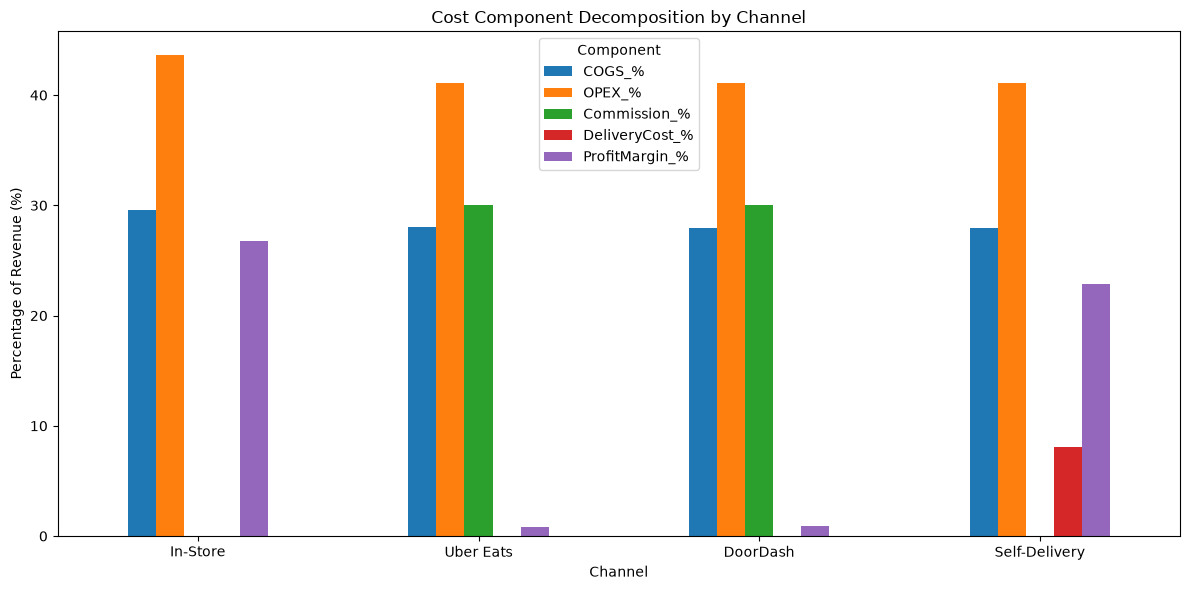

In [339]:
import matplotlib.pyplot as plt

# Prepare data for the cost decomposition chart

plot_data = cost_breakdown.set_index("Channel")[
    ["COGS_%", "OPEX_%", "Commission_%", "DeliveryCost_%", "ProfitMargin_%"]
]

plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cost Component Decomposition by Channel")
plt.xlabel("Channel")
plt.ylabel("Percentage of Revenue (%)")
plt.xticks(rotation=0)
plt.legend(title="Component")
plt.tight_layout()
plt.show()

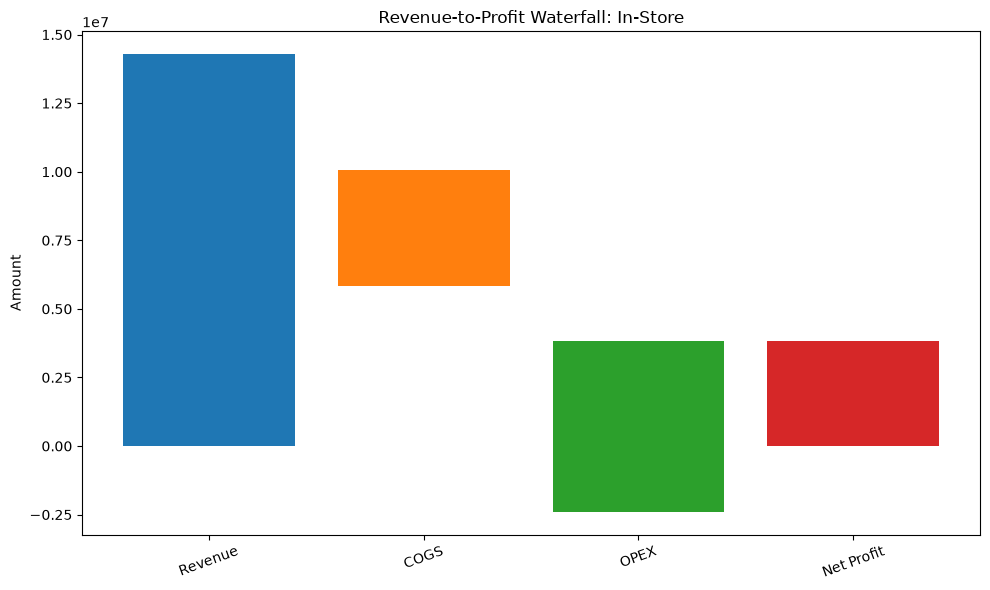

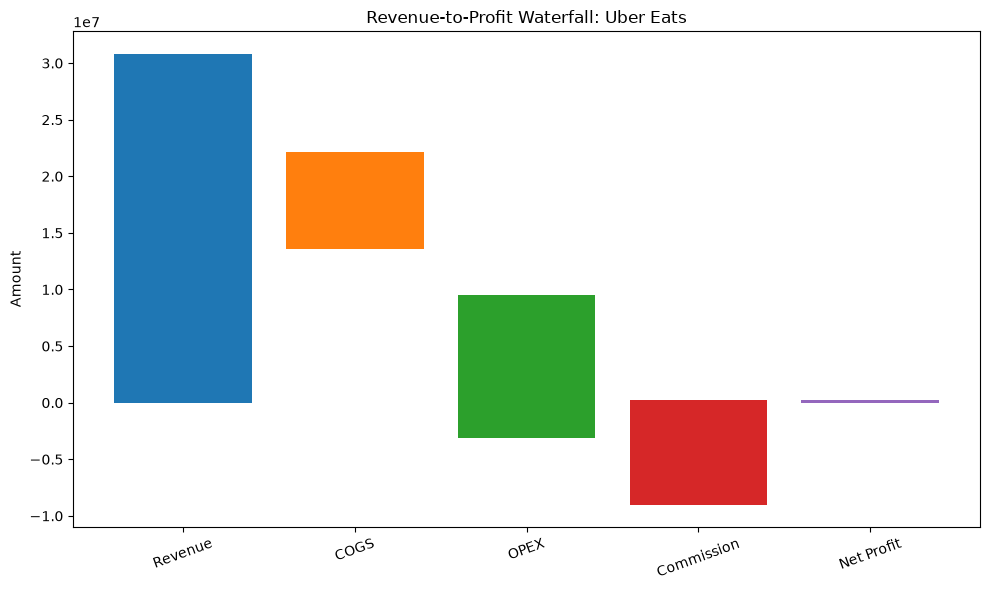

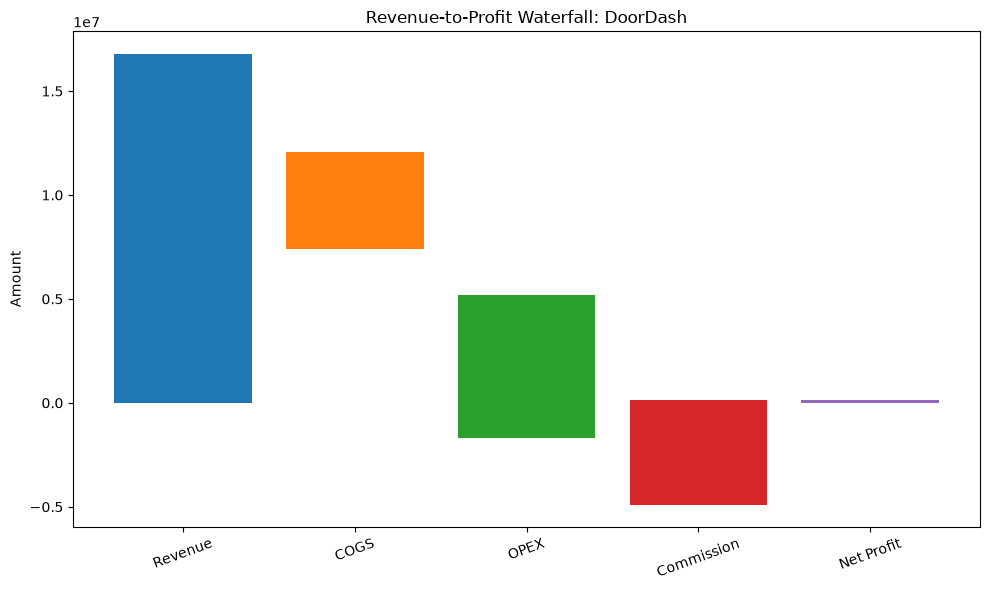

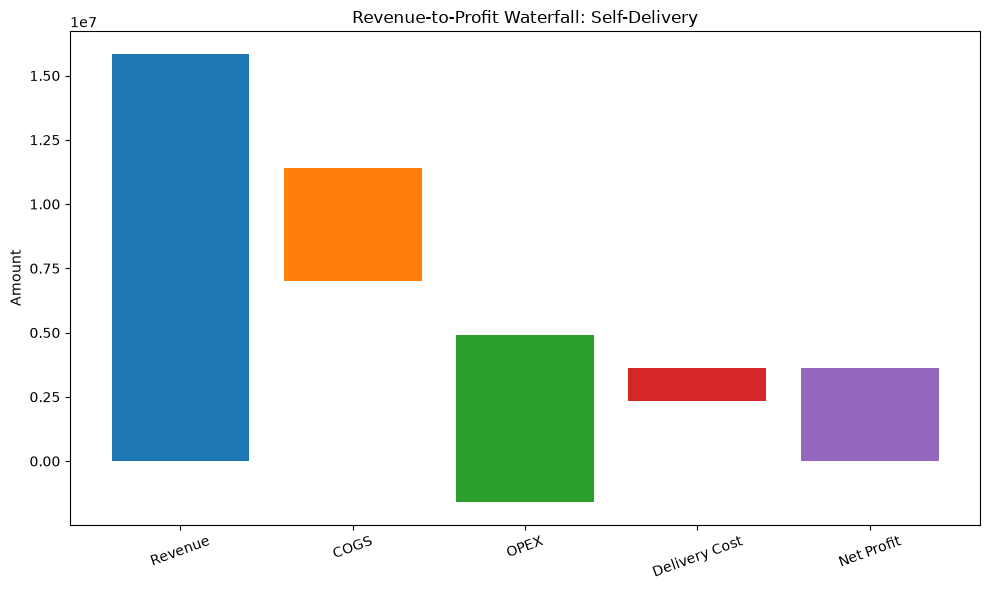

In [340]:
import matplotlib.pyplot as plt

# Create waterfall charts for each channel

channels = cost_breakdown["Channel"].tolist()

for channel in channels:

    row = cost_breakdown[cost_breakdown["Channel"] == channel].iloc[0]

    revenue = row["Revenue"]
    cogs = row["COGS"]
    opex = row["OPEX"]
    commission = row["Commission"]
    delivery = row["DeliveryCost"]
    profit = row["NetProfit"]

    costs = [
        ("COGS", cogs),
        ("OPEX", opex),
        ("Commission", commission),
        ("Delivery Cost", delivery)
    ]

    labels = ["Revenue"]
    values = [revenue]
    bottoms = [0]

    current = revenue

    for name, cost in costs:
        if cost > 0:
            labels.append(name)
            values.append(-cost)
            bottoms.append(current - cost)
            current -= cost

    labels.append("Net Profit")
    values.append(profit)
    bottoms.append(0)

    plt.figure(figsize=(10, 6))

    # Revenue bar
    plt.bar(
        labels[0],
        values[0],
        bottom=bottoms[0]
    )

    # Cost bars
    for i in range(1, len(labels) - 1):
        plt.bar(
            labels[i],
            values[i],
            bottom=bottoms[i]
        )

    # Profit bar
    plt.bar(
        labels[-1],
        values[-1],
        bottom=0
    )

    plt.title(f"Revenue-to-Profit Waterfall: {channel}")
    plt.ylabel("Amount")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

Cost Component Decomposition

The cost decomposition shows that COGS and OPEX represent the major operating cost components across all channels. Aggregator channels additionally incur approximately 30% commission costs, resulting in very low net profit margins of 0.84% for Uber Eats and 0.90% for DoorDash.

Self-Delivery incurs approximately 8.09% of revenue as delivery cost while maintaining a 22.89% net profit margin. In-Store operations have no platform commission or delivery cost in the dataset and achieve a 26.80% net profit margin.

The waterfall analysis demonstrates how revenue is reduced by channel-specific cost components to arrive at net profit.


In [341]:
# Commission sensitivity analysis

commission_scenarios = [0.20, 0.25, 0.30, 0.35, 0.40]

sensitivity_results = []

for rate in commission_scenarios:

    uber_profit = (
        analysis_df["UberEatsRevenue"]
        * (
            1
            - analysis_df["COGSRate"]
            - analysis_df["OPEXRate"]
            - rate
        )
    ).sum()

    doordash_profit = (
        analysis_df["DoorDashRevenue"]
        * (
            1
            - analysis_df["COGSRate"]
            - analysis_df["OPEXRate"]
            - rate
        )
    ).sum()

    sensitivity_results.append({
        "CommissionRate": rate * 100,
        "UberEatsProfit": uber_profit,
        "DoorDashProfit": doordash_profit
    })

commission_sensitivity = pd.DataFrame(sensitivity_results)

commission_sensitivity

,CommissionRate,UberEatsProfit,DoorDashProfit
0,20.0,3.349195e+06,1.834187e+06
1,25.0,1.808376e+06,9.947176e+05
2,30.0,2.675579e+05,1.552486e+05
3,35.0,-1.273261e+06,-6.842204e+05
4,40.0,-2.814079e+06,-1.523689e+06


In [342]:
# Exact break-even commission rate

uber_break_even = (
    (
        analysis_df["UberEatsRevenue"]
        * (
            1
            - analysis_df["COGSRate"]
            - analysis_df["OPEXRate"]
        )
    ).sum()
    / analysis_df["UberEatsRevenue"].sum()
)

doordash_break_even = (
    (
        analysis_df["DoorDashRevenue"]
        * (
            1
            - analysis_df["COGSRate"]
            - analysis_df["OPEXRate"]
        )
    ).sum()
    / analysis_df["DoorDashRevenue"].sum()
)

print("Uber Eats break-even commission rate:",
      round(uber_break_even * 100, 2), "%")

print("DoorDash break-even commission rate:",
      round(doordash_break_even * 100, 2), "%")

Uber Eats break-even commission rate: 30.87 %
DoorDash break-even commission rate: 30.92 %


In [343]:
# Self-Delivery break-even delivery cost per order

self_delivery_operating_profit = (
    analysis_df["SelfDeliveryRevenue"]
    * (
        1
        - analysis_df["COGSRate"]
        - analysis_df["OPEXRate"]
    )
).sum()

total_self_delivery_orders = analysis_df["SelfDeliveryOrders"].sum()

break_even_delivery_cost = (
    self_delivery_operating_profit
    / total_self_delivery_orders
)

current_delivery_cost = (
    analysis_df["SD_DeliveryTotalCost"].sum()
    / total_self_delivery_orders
)

print(
    "Current average delivery cost per order:",
    round(current_delivery_cost, 2)
)

print(
    "Break-even delivery cost per order:",
    round(break_even_delivery_cost, 2)
)

print(
    "Additional delivery cost capacity per order:",
    round(
        break_even_delivery_cost - current_delivery_cost,
        2
    )
)

Current average delivery cost per order: 3.12
Break-even delivery cost per order: 11.94
Additional delivery cost capacity per order: 8.82


In [344]:
# Self-Delivery delivery cost sensitivity

delivery_cost_scenarios = [3, 5, 7, 9, 11, 12, 14]

delivery_sensitivity_results = []

for cost_per_order in delivery_cost_scenarios:

    scenario_delivery_cost = (
        analysis_df["SelfDeliveryOrders"] * cost_per_order
    ).sum()

    scenario_profit = (
        analysis_df["SelfDeliveryRevenue"]
        * (
            1
            - analysis_df["COGSRate"]
            - analysis_df["OPEXRate"]
        )
    ).sum() - scenario_delivery_cost

    delivery_sensitivity_results.append({
        "DeliveryCostPerOrder": cost_per_order,
        "SelfDeliveryProfit": scenario_profit
    })

delivery_sensitivity = pd.DataFrame(
    delivery_sensitivity_results
)

delivery_sensitivity

,DeliveryCostPerOrder,SelfDeliveryProfit
0,3,3.676323e+06
1,5,2.853813e+06
2,7,2.031303e+06
3,9,1.208793e+06
4,11,3.862830e+05
5,12,-2.497203e+04
6,14,-8.474820e+05


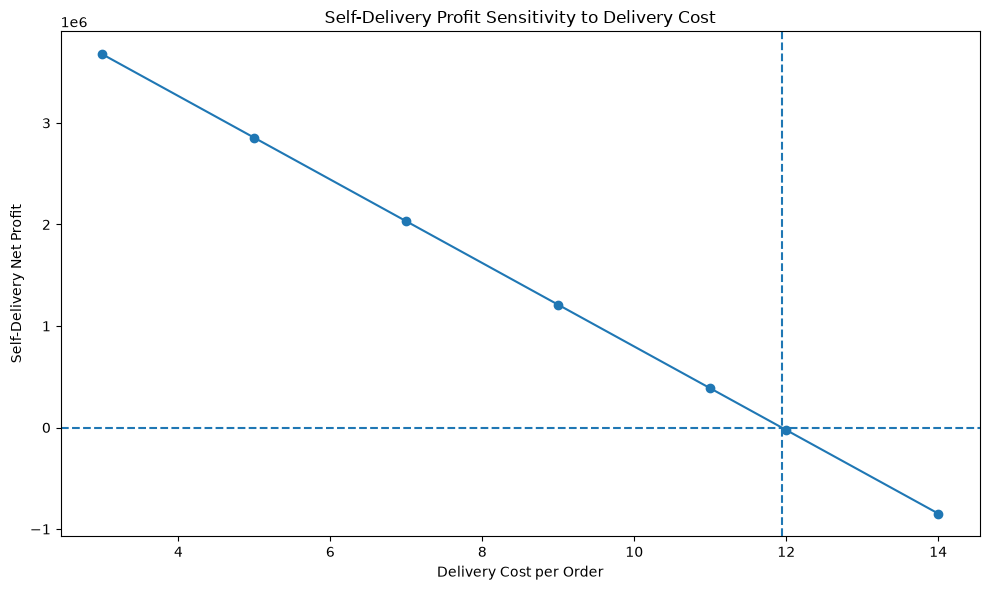

In [345]:
# Self-Delivery delivery cost sensitivity chart

plt.figure(figsize=(10, 6))

plt.plot(
    delivery_sensitivity["DeliveryCostPerOrder"],
    delivery_sensitivity["SelfDeliveryProfit"],
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.axvline(
    x=break_even_delivery_cost,
    linestyle="--"
)

plt.title("Self-Delivery Profit Sensitivity to Delivery Cost")
plt.xlabel("Delivery Cost per Order")
plt.ylabel("Self-Delivery Net Profit")
plt.tight_layout()
plt.show()

Commission and Delivery Cost Sensitivity Analysis

Commission sensitivity analysis shows that aggregator profitability is highly sensitive to commission rates. The calculated aggregate break-even commission rate is approximately 30.87% for Uber Eats and 30.92% for DoorDash. At the current commission level of approximately 30%, both channels generate only a small positive aggregate profit.

Self-Delivery currently has an average delivery cost of approximately $3.12 per order. The aggregate break-even delivery cost is approximately $11.94 per order, providing an additional cost capacity of approximately $8.82 per order before reaching zero profit.

The sensitivity analysis shows that Self-Delivery profit decreases as delivery cost per order increases and becomes negative when delivery cost exceeds the calculated break-even level.

In [346]:
# Channel-wise profitability by cuisine

cuisine_channel = analysis_df.groupby("CuisineType").agg(
    InStoreRevenue=("InStoreRevenue", "sum"),
    InStoreProfit=("InStoreNetProfit", "sum"),
    UberEatsRevenue=("UberEatsRevenue", "sum"),
    UberEatsProfit=("UberEatsNetProfit", "sum"),
    DoorDashRevenue=("DoorDashRevenue", "sum"),
    DoorDashProfit=("DoorDashNetProfit", "sum"),
    SelfDeliveryRevenue=("SelfDeliveryRevenue", "sum"),
    SelfDeliveryProfit=("SelfDeliveryNetProfit", "sum")
).reset_index()

# Calculate channel margins

cuisine_channel["InStoreMargin"] = (
    cuisine_channel["InStoreProfit"] /
    cuisine_channel["InStoreRevenue"] * 100
)

cuisine_channel["UberEatsMargin"] = (
    cuisine_channel["UberEatsProfit"] /
    cuisine_channel["UberEatsRevenue"] * 100
)

cuisine_channel["DoorDashMargin"] = (
    cuisine_channel["DoorDashProfit"] /
    cuisine_channel["DoorDashRevenue"] * 100
)

cuisine_channel["SelfDeliveryMargin"] = (
    cuisine_channel["SelfDeliveryProfit"] /
    cuisine_channel["SelfDeliveryRevenue"] * 100
)

cuisine_channel[
    [
        "CuisineType",
        "InStoreMargin",
        "UberEatsMargin",
        "DoorDashMargin",
        "SelfDeliveryMargin"
    ]
]

,CuisineType,InStoreMargin,UberEatsMargin,DoorDashMargin,SelfDeliveryMargin
0,Burgers,27.419676,1.287770,1.288765,23.061180
1,Chicken Dishes,26.254930,-1.097681,-1.096886,20.747563
2,Chinese,26.435219,1.108703,1.106722,23.279584
3,Indian,26.302845,1.345150,1.344055,23.335212
4,Japanese,28.439548,2.232890,2.232865,24.752798
5,Kebabs/Mediterranean,25.067040,-0.808403,-0.810458,20.787244
6,Pizza,27.012763,0.697995,0.698482,22.693430
7,Thai,26.132930,1.591584,1.591383,23.522089


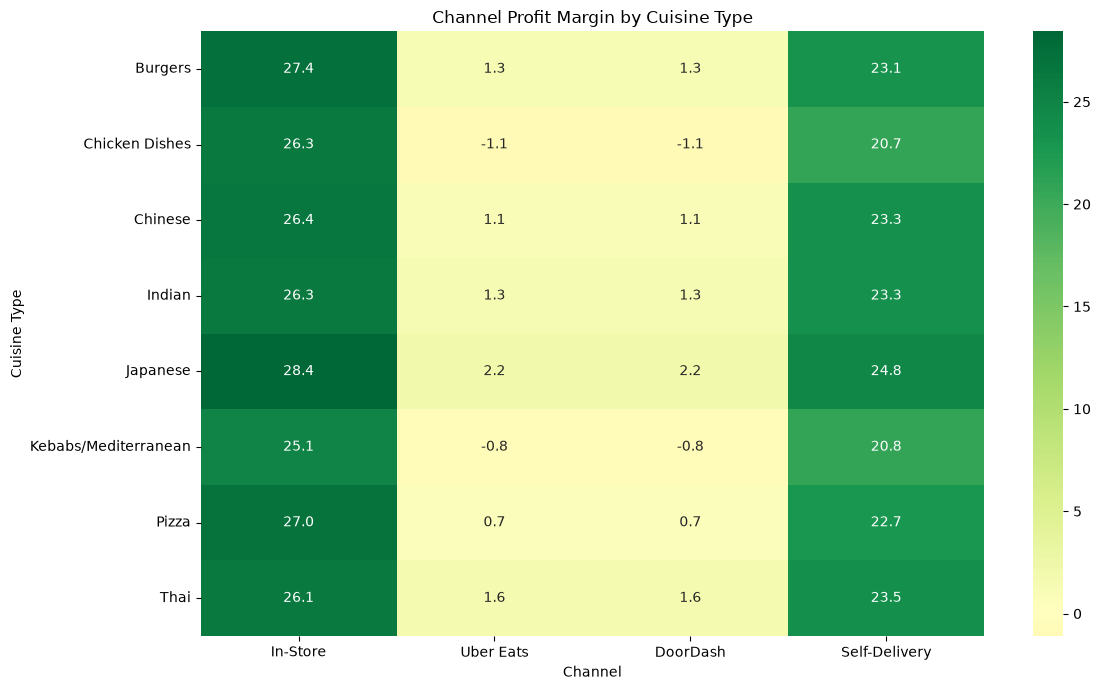

In [347]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare cuisine-channel margin matrix

cuisine_heatmap = cuisine_channel.set_index("CuisineType")[
    [
        "InStoreMargin",
        "UberEatsMargin",
        "DoorDashMargin",
        "SelfDeliveryMargin"
    ]
]

# Rename columns for cleaner display

cuisine_heatmap.columns = [
    "In-Store",
    "Uber Eats",
    "DoorDash",
    "Self-Delivery"
]

plt.figure(figsize=(12, 7))

sns.heatmap(
    cuisine_heatmap,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0
)

plt.title("Channel Profit Margin by Cuisine Type")
plt.xlabel("Channel")
plt.ylabel("Cuisine Type")
plt.tight_layout()
plt.show()

In [348]:
# Channel-wise profitability by business segment

segment_channel = analysis_df.groupby("Segment").agg(
    InStoreRevenue=("InStoreRevenue", "sum"),
    InStoreProfit=("InStoreNetProfit", "sum"),
    UberEatsRevenue=("UberEatsRevenue", "sum"),
    UberEatsProfit=("UberEatsNetProfit", "sum"),
    DoorDashRevenue=("DoorDashRevenue", "sum"),
    DoorDashProfit=("DoorDashNetProfit", "sum"),
    SelfDeliveryRevenue=("SelfDeliveryRevenue", "sum"),
    SelfDeliveryProfit=("SelfDeliveryNetProfit", "sum")
).reset_index()

# Calculate channel margins

segment_channel["InStoreMargin"] = (
    segment_channel["InStoreProfit"] /
    segment_channel["InStoreRevenue"] * 100
)

segment_channel["UberEatsMargin"] = (
    segment_channel["UberEatsProfit"] /
    segment_channel["UberEatsRevenue"] * 100
)

segment_channel["DoorDashMargin"] = (
    segment_channel["DoorDashProfit"] /
    segment_channel["DoorDashRevenue"] * 100
)

segment_channel["SelfDeliveryMargin"] = (
    segment_channel["SelfDeliveryProfit"] /
    segment_channel["SelfDeliveryRevenue"] * 100
)

segment_channel[
    [
        "Segment",
        "InStoreMargin",
        "UberEatsMargin",
        "DoorDashMargin",
        "SelfDeliveryMargin"
    ]
]

,Segment,InStoreMargin,UberEatsMargin,DoorDashMargin,SelfDeliveryMargin
0,Cafe,36.304756,6.091435,6.119366,28.359178
1,Full-service,12.414319,-17.464645,-17.458836,4.079558
2,Ghost Kitchen,45.252319,15.102434,15.123940,37.018862
3,QSR,35.984436,5.847859,5.848353,28.098293


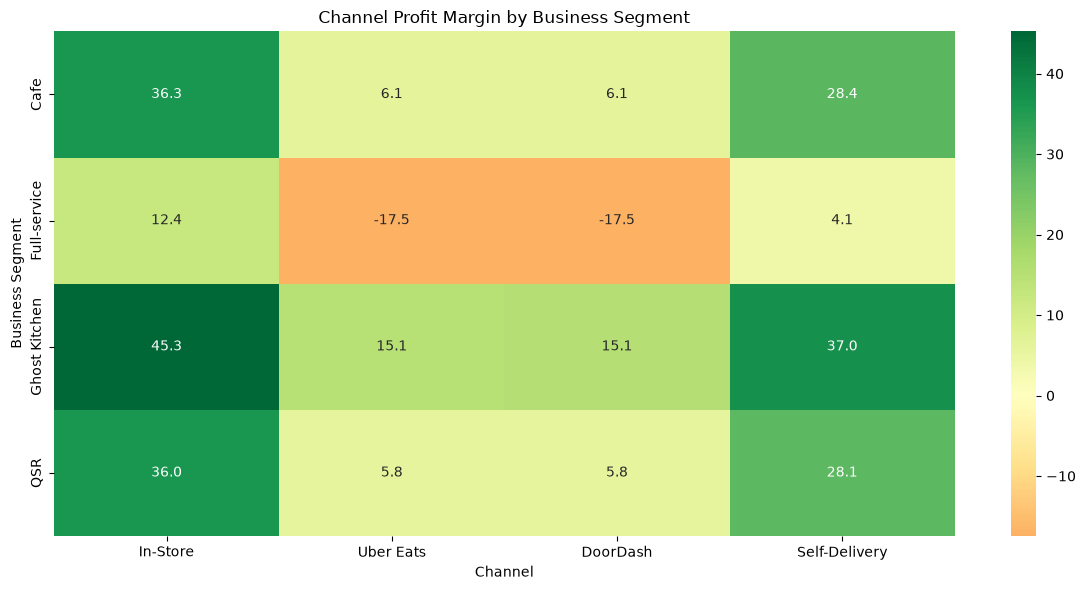

In [349]:
# Prepare segment-channel margin matrix

segment_heatmap = segment_channel.set_index("Segment")[
    [
        "InStoreMargin",
        "UberEatsMargin",
        "DoorDashMargin",
        "SelfDeliveryMargin"
    ]
]

segment_heatmap.columns = [
    "In-Store",
    "Uber Eats",
    "DoorDash",
    "Self-Delivery"
]

plt.figure(figsize=(12, 6))

sns.heatmap(
    segment_heatmap,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0
)

plt.title("Channel Profit Margin by Business Segment")
plt.xlabel("Channel")
plt.ylabel("Business Segment")
plt.tight_layout()
plt.show()

In [350]:
# Identify profitable and loss-making channel combinations

cuisine_classification = cuisine_heatmap.copy()

# Only use the four channel margin columns
margin_columns = [
    "In-Store",
    "Uber Eats",
    "DoorDash",
    "Self-Delivery"
]

# Identify the highest and lowest margin channel
cuisine_classification["MostResilientChannel"] = (
    cuisine_classification[margin_columns].idxmax(axis=1)
)

cuisine_classification["LowestMarginChannel"] = (
    cuisine_classification[margin_columns].idxmin(axis=1)
)

cuisine_classification[
    margin_columns +
    ["MostResilientChannel", "LowestMarginChannel"]
]

,In-Store,Uber Eats,DoorDash,Self-Delivery,MostResilientChannel,LowestMarginChannel
CuisineType,,,,,,
Burgers,27.419676,1.287770,1.288765,23.061180,In-Store,Uber Eats
Chicken Dishes,26.254930,-1.097681,-1.096886,20.747563,In-Store,Uber Eats
Chinese,26.435219,1.108703,1.106722,23.279584,In-Store,DoorDash
Indian,26.302845,1.345150,1.344055,23.335212,In-Store,DoorDash
Japanese,28.439548,2.232890,2.232865,24.752798,In-Store,DoorDash
Kebabs/Mediterranean,25.067040,-0.808403,-0.810458,20.787244,In-Store,DoorDash
Pizza,27.012763,0.697995,0.698482,22.693430,In-Store,Uber Eats
Thai,26.132930,1.591584,1.591383,23.522089,In-Store,DoorDash


In [351]:
# Identify strongest and weakest channel for each business segment

segment_classification = segment_heatmap.copy()

margin_columns = [
    "In-Store",
    "Uber Eats",
    "DoorDash",
    "Self-Delivery"
]

segment_classification["MostResilientChannel"] = (
    segment_classification[margin_columns].idxmax(axis=1)
)

segment_classification["LowestMarginChannel"] = (
    segment_classification[margin_columns].idxmin(axis=1)
)

segment_classification[
    margin_columns +
    ["MostResilientChannel", "LowestMarginChannel"]
]

,In-Store,Uber Eats,DoorDash,Self-Delivery,MostResilientChannel,LowestMarginChannel
Segment,,,,,,
Cafe,36.304756,6.091435,6.119366,28.359178,In-Store,Uber Eats
Full-service,12.414319,-17.464645,-17.458836,4.079558,In-Store,Uber Eats
Ghost Kitchen,45.252319,15.102434,15.123940,37.018862,In-Store,Uber Eats
QSR,35.984436,5.847859,5.848353,28.098293,In-Store,Uber Eats


In [352]:
# Identify negative-margin cuisine-channel combinations

negative_cuisine_combinations = (
    cuisine_heatmap[
        cuisine_heatmap < 0
    ]
    .stack()
    .reset_index()
)

negative_cuisine_combinations.columns = [
    "CuisineType",
    "Channel",
    "ProfitMargin"
]

negative_cuisine_combinations.sort_values(
    "ProfitMargin"
)

,CuisineType,Channel,ProfitMargin
5,Chicken Dishes,Uber Eats,-1.097681
6,Chicken Dishes,DoorDash,-1.096886
22,Kebabs/Mediterranean,DoorDash,-0.810458
21,Kebabs/Mediterranean,Uber Eats,-0.808403
0,Burgers,In-Store,NaN
1,Burgers,Uber Eats,NaN
2,Burgers,DoorDash,NaN
3,Burgers,Self-Delivery,NaN
4,Chicken Dishes,In-Store,NaN
7,Chicken Dishes,Self-Delivery,NaN


In [353]:
# Identify negative-margin segment-channel combinations

negative_segment_combinations = (
    segment_heatmap[
        segment_heatmap < 0
    ]
    .stack()
    .reset_index()
)

negative_segment_combinations.columns = [
    "Segment",
    "Channel",
    "ProfitMargin"
]

negative_segment_combinations.sort_values(
    "ProfitMargin"
)

,Segment,Channel,ProfitMargin
5,Full-service,Uber Eats,-17.464645
6,Full-service,DoorDash,-17.458836
0,Cafe,In-Store,NaN
1,Cafe,Uber Eats,NaN
2,Cafe,DoorDash,NaN
3,Cafe,Self-Delivery,NaN
4,Full-service,In-Store,NaN
7,Full-service,Self-Delivery,NaN
8,Ghost Kitchen,In-Store,NaN
9,Ghost Kitchen,Uber Eats,NaN


Channel × Cuisine & Segment Profitability Analysis

Channel profitability varies across both cuisine types and business segments. The heatmap analysis provides a detailed view of how each channel performs within different operating categories.

Cuisine-level analysis compares In-Store, Uber Eats, DoorDash, and Self-Delivery margins for each cuisine type. This helps identify channel combinations with relatively stronger or weaker profitability.

Segment-level analysis evaluates the same channel margins across Cafe, Full-service, Ghost Kitchen, and QSR operations. Differences between segments highlight how business models influence the financial impact of commissions and delivery costs.

Margin-resilient combinations are identified based on higher observed channel-level profit margins, while margin-fragile combinations are identified through lower or negative margins. These classifications are descriptive and are based on the observed dataset rather than assumptions about future performance.

Negative-margin channel × cuisine and channel × segment combinations are separately identified for further investigation in the profitability and risk analysis.

In [354]:
# Create restaurant-level channel profitability and risk data

risk_df = analysis_df[
    [
        "RestaurantID",
        "RestaurantName",
        "CuisineType",
        "Segment",
        "InStoreMargin",
        "UberEatsMargin",
        "DoorDashMargin",
        "SelfDeliveryMargin",
        "InStoreNetProfit",
        "UberEatsNetProfit",
        "DoorDashNetProfit",
        "SelfDeliveryNetProfit"
    ]
].copy()

risk_df.head()

,RestaurantID,RestaurantName,CuisineType,Segment,InStoreMargin,UberEatsMargin,DoorDashMargin,SelfDeliveryMargin,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit
0,25731,Urban Burgers House,Burgers,Cafe,0.425087,0.145087,0.145087,0.351173,3682.14,1352.45,752.78,2177.19
1,25123,Urban Burgers Diner,Burgers,QSR,0.344171,0.064170,0.064171,0.227484,3605.72,1318.61,731.99,3119.38
2,25177,King Burgers Eatery,Burgers,Cafe,0.372381,0.072381,0.072380,0.291192,7810.95,1555.90,863.42,4172.99
3,25540,Classic Burgers Tavern,Burgers,QSR,0.324893,-0.005106,-0.005106,0.300363,2546.02,-72.25,-40.20,2833.26
4,25258,Lucky Burgers Bistro,Burgers,Cafe,0.345105,0.015106,0.015105,0.267645,3093.09,226.17,125.53,2674.56


In [355]:
# Calculate profit volatility statistics by channel

channel_risk = pd.DataFrame({
    "Channel": [
        "In-Store",
        "Uber Eats",
        "DoorDash",
        "Self-Delivery"
    ],

    "MeanMargin": [
        risk_df["InStoreMargin"].mean() * 100,
        risk_df["UberEatsMargin"].mean() * 100,
        risk_df["DoorDashMargin"].mean() * 100,
        risk_df["SelfDeliveryMargin"].mean() * 100
    ],

    "MedianMargin": [
        risk_df["InStoreMargin"].median() * 100,
        risk_df["UberEatsMargin"].median() * 100,
        risk_df["DoorDashMargin"].median() * 100,
        risk_df["SelfDeliveryMargin"].median() * 100
    ],

    "VolatilityScore": [
        risk_df["InStoreMargin"].std() * 100,
        risk_df["UberEatsMargin"].std() * 100,
        risk_df["DoorDashMargin"].std() * 100,
        risk_df["SelfDeliveryMargin"].std() * 100
    ],

    "MinimumMargin": [
        risk_df["InStoreMargin"].min() * 100,
        risk_df["UberEatsMargin"].min() * 100,
        risk_df["DoorDashMargin"].min() * 100,
        risk_df["SelfDeliveryMargin"].min() * 100
    ],

    "MaximumMargin": [
        risk_df["InStoreMargin"].max() * 100,
        risk_df["UberEatsMargin"].max() * 100,
        risk_df["DoorDashMargin"].max() * 100,
        risk_df["SelfDeliveryMargin"].max() * 100
    ]
})

channel_risk

,Channel,MeanMargin,MedianMargin,VolatilityScore,MinimumMargin,MaximumMargin
0,In-Store,30.820118,34.704682,11.988104,5.460819,54.117403
1,Uber Eats,0.792406,4.652031,12.068527,-25.817530,25.409123
2,DoorDash,0.792408,4.652012,12.068526,-25.817483,25.409165
3,Self-Delivery,22.597175,26.184896,12.593157,-9.899282,51.198854


In [356]:
# Calculate the percentage of restaurants with negative profit by channel

total_restaurants = len(risk_df)

channel_risk["LossMakingRestaurants"] = [
    (risk_df["InStoreNetProfit"] < 0).sum(),
    (risk_df["UberEatsNetProfit"] < 0).sum(),
    (risk_df["DoorDashNetProfit"] < 0).sum(),
    (risk_df["SelfDeliveryNetProfit"] < 0).sum()
]

channel_risk["LossRate_%"] = (
    channel_risk["LossMakingRestaurants"]
    / total_restaurants
    * 100
)

channel_risk

,Channel,MeanMargin,MedianMargin,VolatilityScore,MinimumMargin,MaximumMargin,LossMakingRestaurants,LossRate_%
0,In-Store,30.820118,34.704682,11.988104,5.460819,54.117403,0,0.000000
1,Uber Eats,0.792406,4.652031,12.068527,-25.817530,25.409123,538,31.721698
2,DoorDash,0.792408,4.652012,12.068526,-25.817483,25.409165,538,31.721698
3,Self-Delivery,22.597175,26.184896,12.593157,-9.899282,51.198854,90,5.306604


In [357]:
# Calculate the margin range for each channel

channel_risk["MarginRange"] = (
    channel_risk["MaximumMargin"]
    - channel_risk["MinimumMargin"]
)

channel_risk[
    [
        "Channel",
        "MeanMargin",
        "MedianMargin",
        "VolatilityScore",
        "MarginRange",
        "LossMakingRestaurants",
        "LossRate_%"
    ]
]

,Channel,MeanMargin,MedianMargin,VolatilityScore,MarginRange,LossMakingRestaurants,LossRate_%
0,In-Store,30.820118,34.704682,11.988104,48.656584,0,0.000000
1,Uber Eats,0.792406,4.652031,12.068527,51.226654,538,31.721698
2,DoorDash,0.792408,4.652012,12.068526,51.226648,538,31.721698
3,Self-Delivery,22.597175,26.184896,12.593157,61.098135,90,5.306604


In [358]:
# Count loss-making restaurants by channel

loss_strategy = pd.DataFrame({
    "Channel": [
        "In-Store",
        "Uber Eats",
        "DoorDash",
        "Self-Delivery"
    ],

    "LossMakingRestaurants": [
        (risk_df["InStoreNetProfit"] < 0).sum(),
        (risk_df["UberEatsNetProfit"] < 0).sum(),
        (risk_df["DoorDashNetProfit"] < 0).sum(),
        (risk_df["SelfDeliveryNetProfit"] < 0).sum()
    ]
})

loss_strategy["LossRate_%"] = (
    loss_strategy["LossMakingRestaurants"]
    / total_restaurants
    * 100
)

loss_strategy

,Channel,LossMakingRestaurants,LossRate_%
0,In-Store,0,0.000000
1,Uber Eats,538,31.721698
2,DoorDash,538,31.721698
3,Self-Delivery,90,5.306604


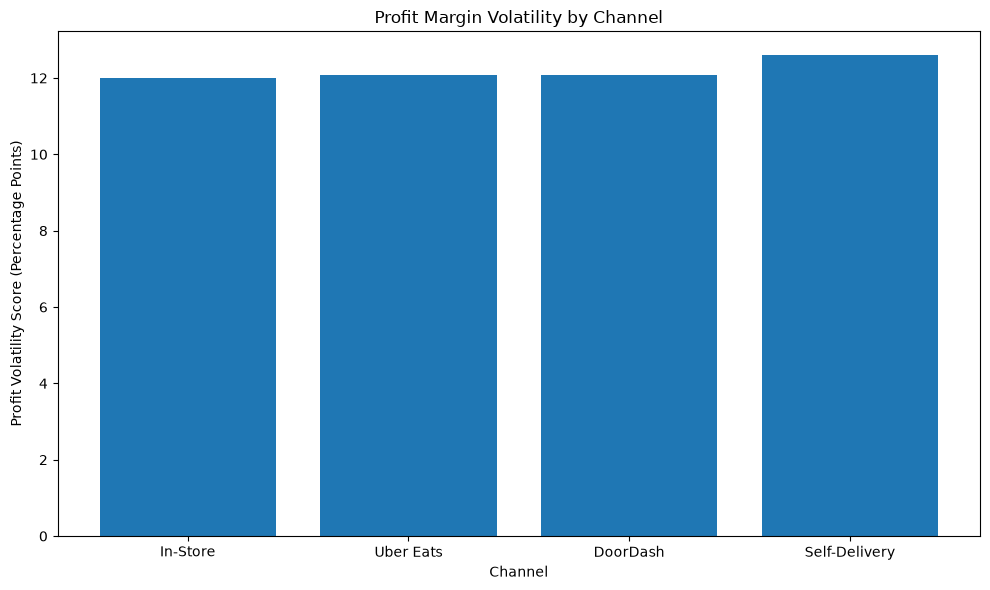

In [359]:
# Profit volatility by channel

plt.figure(figsize=(10, 6))

plt.bar(
    channel_risk["Channel"],
    channel_risk["VolatilityScore"]
)

plt.title("Profit Margin Volatility by Channel")
plt.xlabel("Channel")
plt.ylabel("Profit Volatility Score (Percentage Points)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

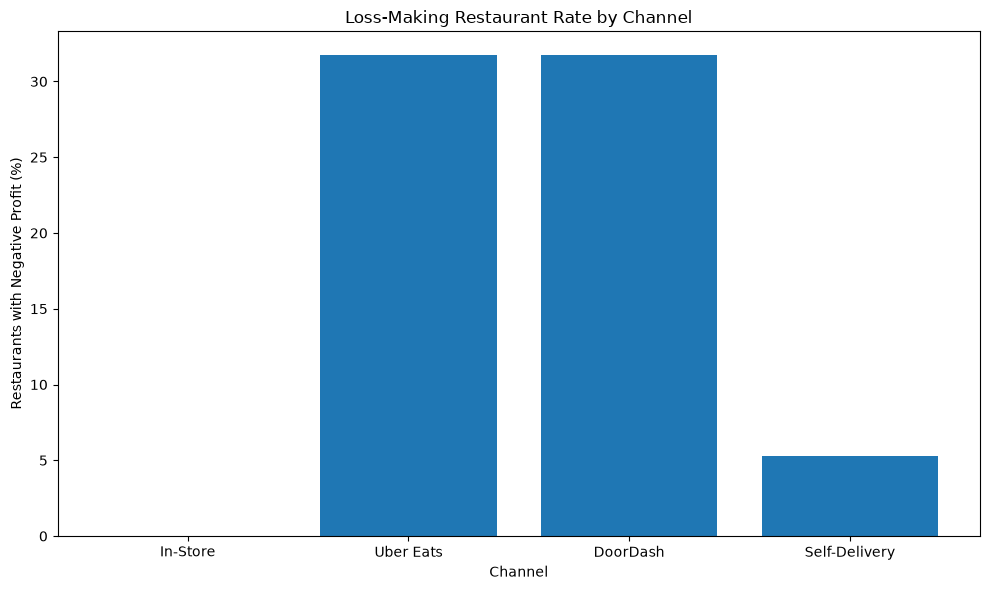

In [360]:
# Loss-making restaurant rate by channel

plt.figure(figsize=(10, 6))

plt.bar(
    loss_strategy["Channel"],
    loss_strategy["LossRate_%"]
)

plt.title("Loss-Making Restaurant Rate by Channel")
plt.xlabel("Channel")
plt.ylabel("Restaurants with Negative Profit (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [361]:
# Final channel risk summary

risk_summary = channel_risk[
    [
        "Channel",
        "MeanMargin",
        "MedianMargin",
        "VolatilityScore",
        "MarginRange",
        "LossMakingRestaurants",
        "LossRate_%"
    ]
].copy()

risk_summary.columns = [
    "Channel",
    "Mean Margin (%)",
    "Median Margin (%)",
    "Profit Volatility Score",
    "Margin Range (pp)",
    "Loss-Making Restaurants",
    "Loss Rate (%)"
]

risk_summary

,Channel,Mean Margin (%),Median Margin (%),Profit Volatility Score,Margin Range (pp),Loss-Making Restaurants,Loss Rate (%)
0,In-Store,30.820118,34.704682,11.988104,48.656584,0,0.000000
1,Uber Eats,0.792406,4.652031,12.068527,51.226654,538,31.721698
2,DoorDash,0.792408,4.652012,12.068526,51.226648,538,31.721698
3,Self-Delivery,22.597175,26.184896,12.593157,61.098135,90,5.306604


Profit Volatility and Risk Analysis

Profit volatility was evaluated using the standard deviation of restaurant-level channel profit margins. The resulting Profit Volatility Score is expressed in percentage points and measures how widely profitability varies across restaurants within each channel.

Loss exposure was measured using the number and percentage of restaurants generating negative net profit for each channel. Margin range was also calculated to identify the spread between the highest and lowest observed restaurant-level margins.

This analysis distinguishes average channel profitability from profitability stability. A channel may generate positive aggregate profit while still having a high proportion of loss-making restaurants. Conversely, a channel with lower variability may provide more consistent margins across restaurants.

The risk analysis therefore considers three dimensions: average margin, margin volatility, and loss rate. These measures are used descriptively to identify unstable and loss-prone channel strategies within the observed dataset.

In [362]:
# KPI Framework

# 1. Net Profit per Order
total_net_profit = analysis_df["TotalNetProfit"].sum()
total_orders = analysis_df["MonthlyOrders"].sum()

net_profit_per_order = (
    total_net_profit / total_orders
)

# 2. Channel Margin %
channel_margin = cost_breakdown[
    ["Channel", "ProfitMargin_%"]
].copy()

channel_margin.columns = [
    "Channel",
    "Channel Margin (%)"
]

# 3. Commission Drag Index
total_commission = (
    analysis_df["UberEatsCommissionCost"].sum()
    + analysis_df["DoorDashCommissionCost"].sum()
)

total_revenue = analysis_df["TotalRevenue"].sum()

commission_drag_index = (
    total_commission / total_revenue * 100
)

# 4. Self-Delivery ROI
self_delivery_profit = (
    analysis_df["SelfDeliveryNetProfit"].sum()
)

self_delivery_cost = (
    analysis_df["SD_DeliveryTotalCost"].sum()
)

self_delivery_roi = (
    self_delivery_profit / self_delivery_cost * 100
)

# 5. Profit Volatility Score
# Defined as standard deviation of restaurant-level channel margins

profit_volatility = risk_summary[
    ["Channel", "Profit Volatility Score"]
].copy()

print("Net Profit per Order:",
      round(net_profit_per_order, 2))

print("Commission Drag Index:",
      round(commission_drag_index, 2), "%")

print("Self-Delivery ROI:",
      round(self_delivery_roi, 2), "%")

print("\nChannel Margin:")
print(channel_margin)

print("\nProfit Volatility Score:")
print(profit_volatility)

Net Profit per Order: 3.9
Commission Drag Index: 18.39 %
Self-Delivery ROI: 283.06 %

Channel Margin:
         Channel  Channel Margin (%)
0       In-Store           26.801428
1      Uber Eats            0.838801
2       DoorDash            0.900106
3  Self-Delivery           22.892536

Profit Volatility Score:
         Channel  Profit Volatility Score
0       In-Store                11.988104
1      Uber Eats                12.068527
2       DoorDash                12.068526
3  Self-Delivery                12.593157


In [363]:
# Create a final KPI summary table

kpi_summary = pd.DataFrame({
    "KPI": [
        "Net Profit per Order",
        "Commission Drag Index",
        "Self-Delivery ROI"
    ],

    "Value": [
        net_profit_per_order,
        commission_drag_index,
        self_delivery_roi
    ],

    "Unit": [
        "$ per order",
        "%",
        "%"
    ]
})

kpi_summary

,KPI,Value,Unit
0,Net Profit per Order,3.895881,$ per order
1,Commission Drag Index,18.388281,%
2,Self-Delivery ROI,283.059107,%


In [364]:
# Channel Margin KPI

channel_margin_kpi = cost_breakdown[
    ["Channel", "Revenue", "NetProfit", "ProfitMargin_%"]
].copy()

channel_margin_kpi.columns = [
    "Channel",
    "Revenue",
    "Net Profit",
    "Channel Margin (%)"
]

channel_margin_kpi

,Channel,Revenue,Net Profit,Channel Margin (%)
0,In-Store,14284378.07,3828417.36,26.801428
1,Uber Eats,30816371.49,258488.08,0.838801
2,DoorDash,16789380.95,151122.25,0.900106
3,Self-Delivery,15849176.29,3628278.44,22.892536


In [365]:
# Profit Volatility KPI

volatility_kpi = risk_summary[
    [
        "Channel",
        "Mean Margin (%)",
        "Profit Volatility Score",
        "Loss Rate (%)"
    ]
].copy()

volatility_kpi

,Channel,Mean Margin (%),Profit Volatility Score,Loss Rate (%)
0,In-Store,30.820118,11.988104,0.000000
1,Uber Eats,0.792406,12.068527,31.721698
2,DoorDash,0.792408,12.068526,31.721698
3,Self-Delivery,22.597175,12.593157,5.306604


In [366]:
# Overall project KPI summary

overall_kpis = pd.DataFrame({
    "KPI": [
        "Net Profit per Order",
        "Commission Drag Index",
        "Self-Delivery ROI"
    ],

    "Value": [
        net_profit_per_order,
        commission_drag_index,
        self_delivery_roi
    ]
})

overall_kpis["Value"] = overall_kpis["Value"].round(2)

overall_kpis

,KPI,Value
0,Net Profit per Order,3.90
1,Commission Drag Index,18.39
2,Self-Delivery ROI,283.06


KPI Framework

Net Profit per Order:
Measures the average net profit generated for each monthly order across the restaurant portfolio.

Channel Margin %:
Measures net profit as a percentage of channel revenue and is used to compare profitability efficiency across In-Store, Uber Eats, DoorDash, and Self-Delivery.

Commission Drag Index:
Measures total aggregator commission cost as a percentage of total restaurant revenue. It quantifies the overall revenue impact of platform commissions.

Self-Delivery ROI:
Measures Self-Delivery net profit relative to total Self-Delivery delivery cost. It evaluates the return generated from the delivery logistics cost.

Profit Volatility Score:
Measures the standard deviation of restaurant-level channel profit margins, expressed in percentage points. A higher score indicates greater variation in profitability across restaurants.

Loss Rate:
Measures the percentage of restaurants generating negative net profit within a specific channel and provides additional context for channel-level risk.

In [367]:
# Overall channel performance summary

channel_performance = cost_breakdown[
    [
        "Channel",
        "Revenue",
        "NetProfit",
        "ProfitMargin_%",
        "COGS",
        "OPEX",
        "Commission",
        "DeliveryCost"
    ]
].copy()

channel_performance

,Channel,Revenue,NetProfit,ProfitMargin_%,COGS,OPEX,Commission,DeliveryCost
0,In-Store,14284378.07,3828417.36,26.801428,4.226914e+06,6.229047e+06,0.000000e+00,0.00
1,Uber Eats,30816371.49,258488.08,0.838801,8.631092e+06,1.267281e+07,9.253981e+06,0.00
2,DoorDash,16789380.95,151122.25,0.900106,4.699249e+06,6.898069e+06,5.040941e+06,0.00
3,Self-Delivery,15849176.29,3628278.44,22.892536,4.428545e+06,6.510543e+06,0.000000e+00,1281809.47


In [368]:
# Add orders and profit per order by channel

channel_orders = {
    "In-Store": analysis_df["InStoreOrders"].sum(),
    "Uber Eats": analysis_df["UberEatsOrders"].sum(),
    "DoorDash": analysis_df["DoorDashOrders"].sum(),
    "Self-Delivery": analysis_df["SelfDeliveryOrders"].sum()
}

channel_performance["Orders"] = (
    channel_performance["Channel"].map(channel_orders)
)

channel_performance["ProfitPerOrder"] = (
    channel_performance["NetProfit"] /
    channel_performance["Orders"]
)

channel_performance[
    [
        "Channel",
        "Revenue",
        "Orders",
        "NetProfit",
        "ProfitMargin_%",
        "ProfitPerOrder"
    ]
]

,Channel,Revenue,Orders,NetProfit,ProfitMargin_%,ProfitPerOrder
0,In-Store,14284378.07,371391,3828417.36,26.801428,10.308320
1,Uber Eats,30816371.49,800353,258488.08,0.838801,0.322968
2,DoorDash,16789380.95,436135,151122.25,0.900106,0.346503
3,Self-Delivery,15849176.29,411255,3628278.44,22.892536,8.822454


In [369]:
# Final analytical findings

final_findings = pd.DataFrame({
    "Metric": [
        "Total Restaurants",
        "Total Revenue",
        "Total Net Profit",
        "Overall Profit Margin",
        "Loss-Making Restaurants",
        "Average Net Profit per Order",
        "Aggregator Commission Drag",
        "Current Self-Delivery Cost per Order",
        "Self-Delivery Break-Even Cost per Order",
        "Uber Eats Break-Even Commission",
        "DoorDash Break-Even Commission"
    ],

    "Value": [
        len(analysis_df),
        analysis_df["TotalRevenue"].sum(),
        analysis_df["TotalNetProfit"].sum(),
        analysis_df["TotalNetProfit"].sum()
        / analysis_df["TotalRevenue"].sum() * 100,
        (analysis_df["TotalNetProfit"] < 0).sum(),
        analysis_df["TotalNetProfit"].sum()
        / analysis_df["MonthlyOrders"].sum(),
        commission_drag_index,
        current_delivery_cost,
        break_even_delivery_cost,
        uber_break_even * 100,
        doordash_break_even * 100
    ]
})

final_findings["Value"] = final_findings["Value"].round(2)

final_findings

,Metric,Value
0,Total Restaurants,1696.00
1,Total Revenue,77739306.80
2,Total Net Profit,7866306.13
3,Overall Profit Margin,10.12
4,Loss-Making Restaurants,408.00
5,Average Net Profit per Order,3.90
6,Aggregator Commission Drag,18.39
7,Current Self-Delivery Cost per Order,3.12
8,Self-Delivery Break-Even Cost per Order,11.94
9,Uber Eats Break-Even Commission,30.87


Business Findings and Recommendations

1. Channel Profitability

The analysis shows substantial differences in profitability across channels. In-Store operations generate a 26.80% net profit margin, while Self-Delivery generates a 22.89% margin. Uber Eats and DoorDash generate much lower aggregate margins of 0.84% and 0.90%, respectively.

2. Aggregator Commission Impact

Uber Eats and DoorDash incur approximately 30% commission costs on their respective revenue. Their calculated break-even commission rates are approximately 30.87% and 30.92%, indicating that the observed commission level is close to the aggregate break-even point.

3. Self-Delivery Economics

Self-Delivery currently has an average delivery cost of approximately $3.12 per order and an aggregate break-even delivery cost of approximately $11.94 per order. The sensitivity analysis shows a progressive decline in profitability as delivery cost increases.

4. Cost Structure

COGS and OPEX are major cost components across all channels. Aggregator channels have the additional burden of platform commissions, while Self-Delivery incurs direct logistics costs.

5. Profit Risk

In-Store has no loss-making restaurants in the analyzed dataset. Uber Eats and DoorDash each have 538 loss-making restaurants, representing approximately 31.72% of the restaurant portfolio. Self-Delivery has 90 loss-making restaurants, representing approximately 5.31%.

6. Cuisine and Segment Differences

Channel profitability varies across cuisine types and business segments. The cuisine and segment heatmaps identify combinations where channel margins are relatively stronger, weaker, or negative.

7. Operational Consideration

The analysis suggests that channel economics should be evaluated at the restaurant, cuisine, and segment levels rather than using a single portfolio-wide margin. Commission rates, delivery costs, operating costs, and channel-specific demand can materially affect individual restaurant profitability.

8. Management Use

The resulting analysis can support channel-level monitoring, cost sensitivity analysis, restaurant-level profitability reviews, and scenario testing for commission and delivery-cost changes.

In [370]:
share_check = df[
    [
        "InStoreShare",
        "CalculatedInStoreShare",
        "UE_share",
        "CalculatedUEShare",
        "DD_share",
        "CalculatedDDShare",
        "SD_share",
        "CalculatedSDShare"
    ]
]

share_check.head(10)

,InStoreShare,CalculatedInStoreShare,UE_share,CalculatedUEShare,DD_share,CalculatedDDShare,SD_share,CalculatedSDShare
0,0.42,0.294910,0.45,0.450106,0.25,0.250531,0.3,0.299363
1,0.23,0.186599,0.45,0.449956,0.25,0.249779,0.3,0.300266
2,0.44,0.305183,0.45,0.450126,0.25,0.249790,0.3,0.300084
3,0.25,0.199446,0.45,0.449827,0.25,0.250288,0.3,0.299885
4,0.27,0.212195,0.45,0.449948,0.25,0.249742,0.3,0.300310
5,0.24,0.193470,0.45,0.449775,0.25,0.250375,0.3,0.299850
6,0.25,0.199773,0.45,0.449645,0.25,0.249645,0.3,0.300709
7,0.10,0.090000,0.45,0.450549,0.25,0.250000,0.3,0.299451
8,0.33,0.248366,0.45,0.450000,0.25,0.250000,0.3,0.300000
9,0.29,0.223776,0.45,0.450450,0.25,0.250000,0.3,0.299550


In [371]:
df[
    [
        "InStoreShare",
        "UE_share",
        "DD_share",
        "SD_share"
    ]
].describe()

,InStoreShare,UE_share,DD_share,SD_share
count,1696.000000,1696.000000,1696.000000,1696.000000
mean,0.225654,0.486763,0.265242,0.247995
std,0.126977,0.067685,0.034294,0.094582
min,0.030000,0.350000,0.200000,0.150000
25%,0.110000,0.450000,0.250000,0.150000
50%,0.210000,0.500000,0.250000,0.200000
75%,0.320000,0.550000,0.300000,0.300000
max,0.550000,0.600000,0.300000,0.450000


In [372]:
df["CalculatedDeliveryShareSum"] = (
    df["CalculatedUEShare"]
    + df["CalculatedDDShare"]
    + df["CalculatedSDShare"]
)

df["ProvidedDeliveryShareSum"] = (
    df["UE_share"]
    + df["DD_share"]
    + df["SD_share"]
)

print("Average calculated delivery share:",
      df["CalculatedDeliveryShareSum"].mean())

print("Average provided delivery share:",
      df["ProvidedDeliveryShareSum"].mean())

print(
    "Rows where provided delivery shares differ from 1 by > 0.01:",
    (abs(df["ProvidedDeliveryShareSum"] - 1) > 0.01).sum()
)

print(
    "Rows where calculated delivery shares differ from 1 by > 0.01:",
    (abs(df["CalculatedDeliveryShareSum"] - 1) > 0.01).sum()
)

Average calculated delivery share: 1.0
Average provided delivery share: 1.0
Rows where provided delivery shares differ from 1 by > 0.01: 0
Rows where calculated delivery shares differ from 1 by > 0.01: 0


In [373]:
df[
    [
        "MonthlyOrders",
        "InStoreOrders",
        "UberEatsOrders",
        "DoorDashOrders",
        "SelfDeliveryOrders",
        "InStoreShare",
        "UE_share",
        "DD_share",
        "SD_share"
    ]
].head(10)

,MonthlyOrders,InStoreOrders,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders,InStoreShare,UE_share,DD_share,SD_share
0,668,197,212,118,141,0.42,0.45,0.25,0.3
1,1388,259,508,282,339,0.23,0.45,0.25,0.3
2,1717,524,537,298,358,0.44,0.45,0.25,0.3
3,1083,216,390,217,260,0.25,0.45,0.25,0.3
4,1230,261,436,242,291,0.27,0.45,0.25,0.3
5,827,160,300,167,200,0.24,0.45,0.25,0.3
6,881,176,317,176,212,0.25,0.45,0.25,0.3
7,800,72,328,182,218,0.10,0.45,0.25,0.3
8,612,152,207,115,138,0.33,0.45,0.25,0.3
9,572,128,200,111,133,0.29,0.45,0.25,0.3


Data Validation Findings

The dataset contains 1,696 restaurant records and 30 variables.

The validation process confirmed that:

- Monthly order totals reconcile exactly with the sum of channel-level orders.
- Channel revenues are consistent with AOV multiplied by channel order volume.
- In-store, Uber Eats, and DoorDash net profit calculations reconcile with the specified COGS, OPEX, and commission formulas.
- Self-delivery logistics cost reconciles with self-delivery orders multiplied by delivery cost per order.
- Self-delivery net profit reconciles with revenue, COGS, OPEX, and delivery logistics cost.
- Uber Eats, DoorDash, and Self-Delivery shares collectively sum to 100% of delivery orders across all records.

A data-quality inconsistency was identified in the provided `InStoreShare` field. The supplied values do not reconcile with `InStoreOrders / MonthlyOrders`. Therefore, the original `InStoreShare` field will be retained as a source variable, while a validated `CalculatedInStoreShare` variable will be used for analytical calculations. 

In [374]:
analysis_df = df.copy()

print("Analysis dataset created successfully")
print("Shape:", analysis_df.shape)

Analysis dataset created successfully
Shape: (1696, 57)


In [375]:
analysis_df["ValidatedInStoreShare"] = (
    analysis_df["InStoreOrders"] /
    analysis_df["MonthlyOrders"]
)

In [376]:
analysis_df[
    [
        "InStoreShare",
        "ValidatedInStoreShare"
    ]
].head(10)

,InStoreShare,ValidatedInStoreShare
0,0.42,0.294910
1,0.23,0.186599
2,0.44,0.305183
3,0.25,0.199446
4,0.27,0.212195
5,0.24,0.193470
6,0.25,0.199773
7,0.10,0.090000
8,0.33,0.248366
9,0.29,0.223776


In [377]:
analysis_df["TotalRevenue"] = (
    analysis_df["InStoreRevenue"]
    + analysis_df["UberEatsRevenue"]
    + analysis_df["DoorDashRevenue"]
    + analysis_df["SelfDeliveryRevenue"]
)

In [378]:
analysis_df["TotalNetProfit"] = (
    analysis_df["InStoreNetProfit"]
    + analysis_df["UberEatsNetProfit"]
    + analysis_df["DoorDashNetProfit"]
    + analysis_df["SelfDeliveryNetProfit"]
)

In [379]:
analysis_df["TotalNetProfit"].head()

0     7964.56
1     8775.70
2    14403.26
3     5266.83
4     6119.35
Name: TotalNetProfit, dtype: float64

In [380]:
analysis_df["OverallProfitMargin"] = (
    analysis_df["TotalNetProfit"] /
    analysis_df["TotalRevenue"]
)

In [381]:
analysis_df["TotalDeliveryOrders"] = (
    analysis_df["UberEatsOrders"]
    + analysis_df["DoorDashOrders"]
    + analysis_df["SelfDeliveryOrders"]
)

In [382]:
analysis_df["NetProfitPerOrder"] = (
    analysis_df["TotalNetProfit"] /
    analysis_df["MonthlyOrders"]
)

In [383]:
analysis_df["InStoreProfitPerOrder"] = (
    analysis_df["InStoreNetProfit"] /
    analysis_df["InStoreOrders"]
)
analysis_df["UberEatsProfitPerOrder"] = (
    analysis_df["UberEatsNetProfit"] /
    analysis_df["UberEatsOrders"]
)
analysis_df["DoorDashProfitPerOrder"] = (
    analysis_df["DoorDashNetProfit"] /
    analysis_df["DoorDashOrders"]
)
analysis_df["SelfDeliveryProfitPerOrder"] = (
    analysis_df["SelfDeliveryNetProfit"] /
    analysis_df["SelfDeliveryOrders"]
)

In [384]:
analysis_df["InStoreMargin"] = (
    analysis_df["InStoreNetProfit"] /
    analysis_df["InStoreRevenue"]
)
analysis_df["UberEatsMargin"] = (
    analysis_df["UberEatsNetProfit"] /
    analysis_df["UberEatsRevenue"]
)
analysis_df["DoorDashMargin"] = (
    analysis_df["DoorDashNetProfit"] /
    analysis_df["DoorDashRevenue"]
)
analysis_df["SelfDeliveryMargin"] = (
    analysis_df["SelfDeliveryNetProfit"] /
    analysis_df["SelfDeliveryRevenue"]
)

In [385]:
analysis_df["UberEatsCommissionCost"] = (
    analysis_df["UberEatsRevenue"] *
    analysis_df["CommissionRate"]
)
analysis_df["DoorDashCommissionCost"] = (
    analysis_df["DoorDashRevenue"] *
    analysis_df["CommissionRate"]
)
analysis_df["TotalCommissionCost"] = (
    analysis_df["UberEatsCommissionCost"]
    + analysis_df["DoorDashCommissionCost"]
)

In [386]:
analysis_df["CommissionDragIndex"] = (
    analysis_df["TotalCommissionCost"] /
    analysis_df["TotalRevenue"]
)

In [387]:
analysis_df["SelfDeliveryCostRatio"] = (
    analysis_df["SD_DeliveryTotalCost"] /
    analysis_df["SelfDeliveryRevenue"]
)

In [388]:
analysis_df["SelfDeliveryROI"] = (
    analysis_df["SelfDeliveryNetProfit"] /
    analysis_df["SD_DeliveryTotalCost"]
)

In [389]:
analysis_df[
    [
        "RestaurantName",
        "TotalRevenue",
        "TotalNetProfit",
        "OverallProfitMargin",
        "NetProfitPerOrder",
        "InStoreProfitPerOrder",
        "UberEatsProfitPerOrder",
        "DoorDashProfitPerOrder",
        "SelfDeliveryProfitPerOrder",
        "CommissionDragIndex",
        "SelfDeliveryCostRatio",
        "SelfDeliveryROI"
    ]
].head(10)

,RestaurantName,TotalRevenue,TotalNetProfit,OverallProfitMargin,NetProfitPerOrder,InStoreProfitPerOrder,UberEatsProfitPerOrder,DoorDashProfitPerOrder,SelfDeliveryProfitPerOrder,CommissionDragIndex,SelfDeliveryCostRatio,SelfDeliveryROI
0,Urban Burgers House,29371.96,7964.56,0.271162,11.922994,18.691066,6.379481,6.379492,15.441064,0.138323,0.073914,4.751097
1,Urban Burgers Diner,56144.60,8775.70,0.156305,6.322550,13.921699,2.595689,2.595709,9.201711,0.159366,0.116687,1.949515
2,King Burgers Eatery,68731.51,14403.26,0.209558,8.388620,14.906393,2.897393,2.897383,11.656397,0.145894,0.081189,3.586584
3,Classic Burgers Tavern,39291.24,5266.83,0.134046,4.863186,11.787130,-0.185256,-0.185253,10.897154,0.184958,0.024531,12.243993
4,Lucky Burgers Bistro,42238.20,6119.35,0.144877,4.975081,11.850920,0.518739,0.518719,9.190928,0.181902,0.077461,3.455236
5,King Burgers Kitchen,30499.76,4582.50,0.150247,5.541112,12.509250,1.814067,1.814072,8.669250,0.163761,0.104121,2.257617
6,Urban Burgers Eatery,40807.92,9608.97,0.235468,10.906890,18.662670,5.693091,5.693068,16.592689,0.156686,0.044689,8.015792
7,Urban Burgers Tavern,27792.00,5056.68,0.181947,6.320850,14.633333,3.863933,3.863901,9.323303,0.197625,0.152850,1.755801
8,Classic Burgers Tavern,20067.48,3426.42,0.170745,5.598725,11.306579,1.469565,1.469565,8.946522,0.157843,0.071973,3.790899
9,Lucky Burgers Cafe,20632.04,3748.22,0.181670,6.552832,12.603594,2.864750,2.864685,9.353609,0.146801,0.090103,2.878034


In [390]:
analysis_df[
    [
        "MonthlyOrders",
        "AOV",
        "TotalRevenue",
        "TotalNetProfit",
        "OverallProfitMargin",
        "NetProfitPerOrder",
        "CommissionDragIndex",
        "SelfDeliveryCostRatio",
        "SelfDeliveryROI"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
MonthlyOrders,1696.0,1190.527123,422.334848,441.000000,827.000000,1182.000000,1525.000000,2337.000000
AOV,1696.0,38.516887,4.459408,29.790000,34.787500,38.340000,42.495000,47.230000
TotalRevenue,1696.0,45836.855425,17142.765393,14106.420000,31539.740000,44686.005000,58178.865000,100888.290000
TotalNetProfit,1696.0,4638.152199,5829.596215,-10192.830000,556.615000,4932.860000,8419.292500,27368.360000
OverallProfitMargin,1696.0,0.104457,0.112116,-0.176629,0.010080,0.134985,0.186511,0.343075
NetProfitPerOrder,1696.0,4.065952,4.397374,-6.591778,0.402892,5.077106,7.202661,15.613339
CommissionDragIndex,1696.0,0.187192,0.036445,0.099650,0.159492,0.192495,0.214881,0.264298
SelfDeliveryCostRatio,1696.0,0.082229,0.037158,0.019214,0.049895,0.082063,0.111620,0.170356
SelfDeliveryROI,1696.0,3.974776,3.852994,-0.581093,1.503539,2.762462,5.240450,26.491092


In [391]:
print("Cuisine types:", analysis_df["CuisineType"].nunique())
print("Segments:", analysis_df["Segment"].nunique())
print("Subregions:", analysis_df["Subregion"].nunique())

Cuisine types: 8
Segments: 4
Subregions: 4


In [392]:
print("\nCuisine distribution:")
print(analysis_df["CuisineType"].value_counts())


Cuisine distribution:
CuisineType
Burgers                 375
Indian                  329
Pizza                   219
Chinese                 218
Kebabs/Mediterranean    167
Chicken Dishes          148
Japanese                120
Thai                    120
Name: count, dtype: int64


In [393]:
print("\nCuisine distribution:")
print(analysis_df["CuisineType"].value_counts())


Cuisine distribution:
CuisineType
Burgers                 375
Indian                  329
Pizza                   219
Chinese                 218
Kebabs/Mediterranean    167
Chicken Dishes          148
Japanese                120
Thai                    120
Name: count, dtype: int64


In [394]:
print("\nSegment distribution:")
print(analysis_df["Segment"].value_counts())


Segment distribution:
Segment
QSR              543
Cafe             504
Full-service     452
Ghost Kitchen    197
Name: count, dtype: int64


In [395]:
print("\nSubregion distribution:")
print(analysis_df["Subregion"].value_counts())


Subregion distribution:
Subregion
West Auckland     462
South Auckland    441
CBD               410
North Shore       383
Name: count, dtype: int64


In [396]:
channel_summary = pd.DataFrame({
    "Channel": [
        "In-Store",
        "Uber Eats",
        "DoorDash",
        "Self-Delivery"
    ],
    
    "Revenue": [
        analysis_df["InStoreRevenue"].sum(),
        analysis_df["UberEatsRevenue"].sum(),
        analysis_df["DoorDashRevenue"].sum(),
        analysis_df["SelfDeliveryRevenue"].sum()
    ],
    
    "Net Profit": [
        analysis_df["InStoreNetProfit"].sum(),
        analysis_df["UberEatsNetProfit"].sum(),
        analysis_df["DoorDashNetProfit"].sum(),
        analysis_df["SelfDeliveryNetProfit"].sum()
    ],
    
    "Orders": [
        analysis_df["InStoreOrders"].sum(),
        analysis_df["UberEatsOrders"].sum(),
        analysis_df["DoorDashOrders"].sum(),
        analysis_df["SelfDeliveryOrders"].sum()
    ]
})

channel_summary

,Channel,Revenue,Net Profit,Orders
0,In-Store,14284378.07,3828417.36,371391
1,Uber Eats,30816371.49,258488.08,800353
2,DoorDash,16789380.95,151122.25,436135
3,Self-Delivery,15849176.29,3628278.44,411255


In [397]:
channel_summary["Margin %"] = (
    channel_summary["Net Profit"] /
    channel_summary["Revenue"]
)

channel_summary["Profit per Order"] = (
    channel_summary["Net Profit"] /
    channel_summary["Orders"]
)

channel_summary

,Channel,Revenue,Net Profit,Orders,Margin %,Profit per Order
0,In-Store,14284378.07,3828417.36,371391,0.268014,10.308320
1,Uber Eats,30816371.49,258488.08,800353,0.008388,0.322968
2,DoorDash,16789380.95,151122.25,436135,0.009001,0.346503
3,Self-Delivery,15849176.29,3628278.44,411255,0.228925,8.822454


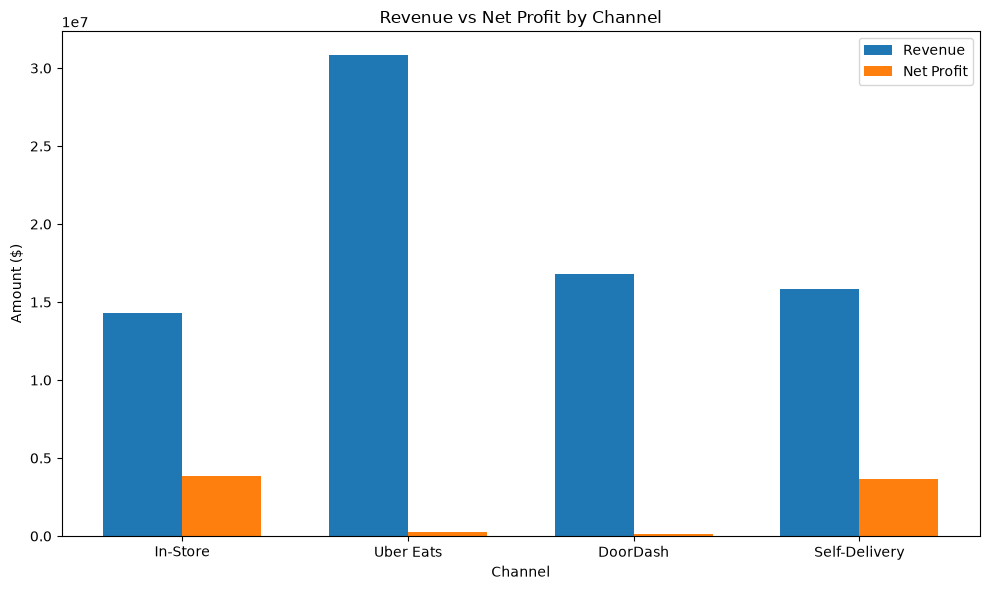

In [398]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(channel_summary["Channel"]))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width/2,
    channel_summary["Revenue"],
    width,
    label="Revenue"
)

ax.bar(
    x + width/2,
    channel_summary["Net Profit"],
    width,
    label="Net Profit"
)

ax.set_xlabel("Channel")
ax.set_ylabel("Amount ($)")
ax.set_title("Revenue vs Net Profit by Channel")
ax.set_xticks(x)
ax.set_xticklabels(channel_summary["Channel"])
ax.legend()

plt.tight_layout()
plt.show()

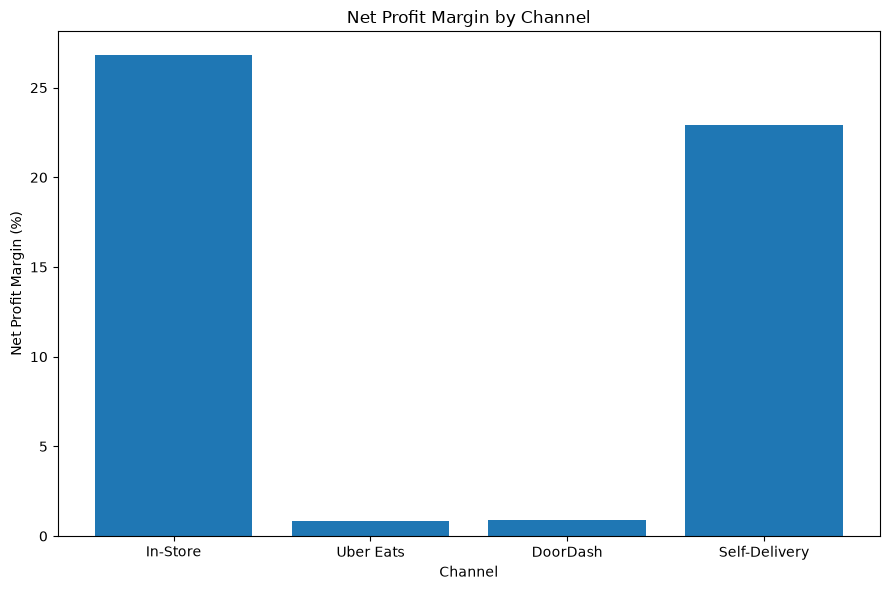

In [399]:
plt.figure(figsize=(9, 6))

plt.bar(
    channel_summary["Channel"],
    channel_summary["Margin %"] * 100
)

plt.xlabel("Channel")
plt.ylabel("Net Profit Margin (%)")
plt.title("Net Profit Margin by Channel")

plt.tight_layout()
plt.show()

In [400]:
commission_summary = pd.DataFrame({
    "Channel": ["Uber Eats", "DoorDash"],
    
    "Revenue": [
        analysis_df["UberEatsRevenue"].sum(),
        analysis_df["DoorDashRevenue"].sum()
    ],
    
    "Commission Cost": [
        analysis_df["UberEatsCommissionCost"].sum(),
        analysis_df["DoorDashCommissionCost"].sum()
    ],
    
    "Net Profit": [
        analysis_df["UberEatsNetProfit"].sum(),
        analysis_df["DoorDashNetProfit"].sum()
    ]
})

commission_summary["Commission % of Revenue"] = (
    commission_summary["Commission Cost"] /
    commission_summary["Revenue"]
)

commission_summary

,Channel,Revenue,Commission Cost,Net Profit,Commission % of Revenue
0,Uber Eats,30816371.49,9.253981e+06,258488.08,0.300294
1,DoorDash,16789380.95,5.040941e+06,151122.25,0.300246


In [401]:
commission_summary["Commission % of Revenue"] = (
    commission_summary["Commission % of Revenue"] * 100
)

commission_summary

,Channel,Revenue,Commission Cost,Net Profit,Commission % of Revenue
0,Uber Eats,30816371.49,9.253981e+06,258488.08,30.029432
1,DoorDash,16789380.95,5.040941e+06,151122.25,30.024578


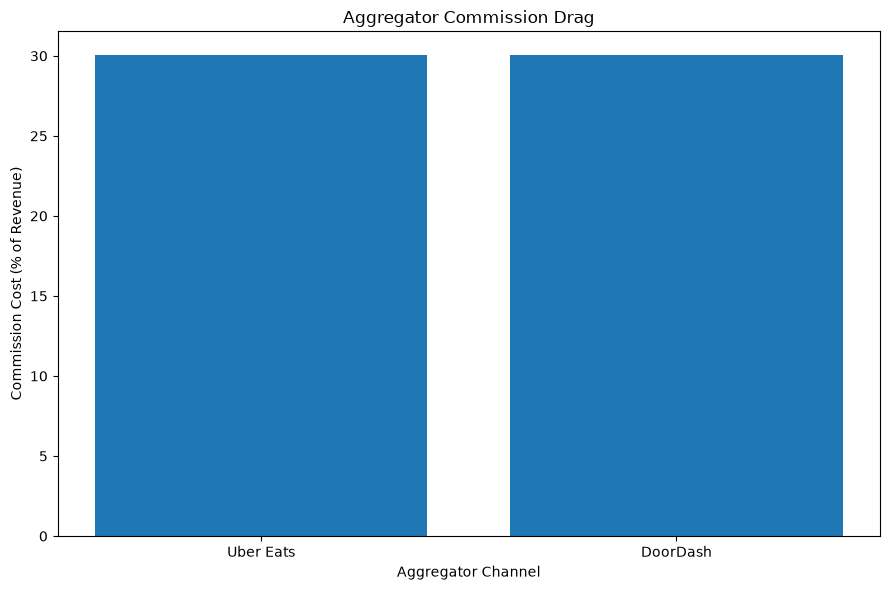

In [402]:
plt.figure(figsize=(9, 6))

plt.bar(
    commission_summary["Channel"],
    commission_summary["Commission % of Revenue"]
)

plt.xlabel("Aggregator Channel")
plt.ylabel("Commission Cost (% of Revenue)")
plt.title("Aggregator Commission Drag")

plt.tight_layout()
plt.show()

In [403]:
analysis_df["UberEatsProfitBeforeCommission"] = (
    analysis_df["UberEatsNetProfit"]
    + analysis_df["UberEatsCommissionCost"]
)

analysis_df["DoorDashProfitBeforeCommission"] = (
    analysis_df["DoorDashNetProfit"]
    + analysis_df["DoorDashCommissionCost"]
)

In [404]:
commission_impact = pd.DataFrame({
    "Channel": ["Uber Eats", "DoorDash"],
    
    "Profit Before Commission": [
        analysis_df["UberEatsProfitBeforeCommission"].sum(),
        analysis_df["DoorDashProfitBeforeCommission"].sum()
    ],
    
    "Commission Cost": [
        analysis_df["UberEatsCommissionCost"].sum(),
        analysis_df["DoorDashCommissionCost"].sum()
    ],
    
    "Profit After Commission": [
        analysis_df["UberEatsNetProfit"].sum(),
        analysis_df["DoorDashNetProfit"].sum()
    ]
})

commission_impact

,Channel,Profit Before Commission,Commission Cost,Profit After Commission
0,Uber Eats,9.512469e+06,9.253981e+06,258488.08
1,DoorDash,5.192063e+06,5.040941e+06,151122.25


In [405]:
cuisine_profitability = (
    analysis_df
    .groupby("CuisineType")
    .agg(
        Restaurants=("RestaurantID", "count"),
        TotalRevenue=("TotalRevenue", "sum"),
        TotalProfit=("TotalNetProfit", "sum"),
        TotalOrders=("MonthlyOrders", "sum")
    )
    .reset_index()
)

cuisine_profitability["ProfitMargin"] = (
    cuisine_profitability["TotalProfit"] /
    cuisine_profitability["TotalRevenue"]
)

cuisine_profitability["ProfitPerOrder"] = (
    cuisine_profitability["TotalProfit"] /
    cuisine_profitability["TotalOrders"]
)

cuisine_profitability

,CuisineType,Restaurants,TotalRevenue,TotalProfit,TotalOrders,ProfitMargin,ProfitPerOrder
0,Burgers,375,18771503.37,2327693.48,484875,0.124001,4.800605
1,Chicken Dishes,148,7106663.66,558387.64,182973,0.078572,3.051749
2,Chinese,218,10013978.81,1012118.27,261406,0.101071,3.871825
3,Indian,329,13615825.12,1131201.93,354051,0.083080,3.195025
4,Japanese,120,5208643.91,442374.96,134875,0.084931,3.279888
5,Kebabs/Mediterranean,167,6919985.85,367121.18,181890,0.053052,2.018369
6,Pizza,219,11045190.86,1599877.75,286445,0.144848,5.585288
7,Thai,120,5057515.22,427530.92,132619,0.084534,3.223753


In [406]:
cuisine_profitability.sort_values(
    "ProfitMargin",
    ascending=False
)

,CuisineType,Restaurants,TotalRevenue,TotalProfit,TotalOrders,ProfitMargin,ProfitPerOrder
6,Pizza,219,11045190.86,1599877.75,286445,0.144848,5.585288
0,Burgers,375,18771503.37,2327693.48,484875,0.124001,4.800605
2,Chinese,218,10013978.81,1012118.27,261406,0.101071,3.871825
4,Japanese,120,5208643.91,442374.96,134875,0.084931,3.279888
7,Thai,120,5057515.22,427530.92,132619,0.084534,3.223753
3,Indian,329,13615825.12,1131201.93,354051,0.083080,3.195025
1,Chicken Dishes,148,7106663.66,558387.64,182973,0.078572,3.051749
5,Kebabs/Mediterranean,167,6919985.85,367121.18,181890,0.053052,2.018369


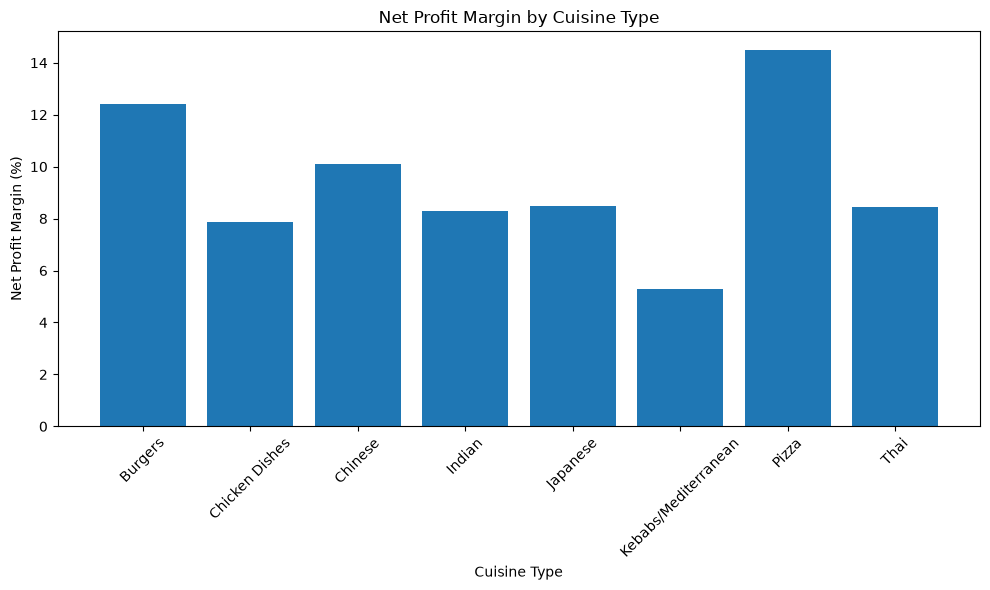

In [407]:
plt.figure(figsize=(10, 6))

plt.bar(
    cuisine_profitability["CuisineType"],
    cuisine_profitability["ProfitMargin"] * 100
)

plt.xlabel("Cuisine Type")
plt.ylabel("Net Profit Margin (%)")
plt.title("Net Profit Margin by Cuisine Type")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [408]:
segment_profitability = (
    analysis_df
    .groupby("Segment")
    .agg(
        Restaurants=("RestaurantID", "count"),
        TotalRevenue=("TotalRevenue", "sum"),
        TotalProfit=("TotalNetProfit", "sum"),
        TotalOrders=("MonthlyOrders", "sum")
    )
    .reset_index()
)

segment_profitability["ProfitMargin"] = (
    segment_profitability["TotalProfit"] /
    segment_profitability["TotalRevenue"]
)

segment_profitability["ProfitPerOrder"] = (
    segment_profitability["TotalProfit"] /
    segment_profitability["TotalOrders"]
)

segment_profitability

,Segment,Restaurants,TotalRevenue,TotalProfit,TotalOrders,ProfitMargin,ProfitPerOrder
0,Cafe,504,23247488.68,3770700.40,601725,0.162198,6.266485
1,Full-service,452,22589867.07,-1301777.83,593042,-0.057627,-2.195085
2,Ghost Kitchen,197,8030853.78,1783066.46,208769,0.222027,8.540858
3,QSR,543,23871097.27,3614317.10,615598,0.151410,5.871229


In [409]:
segment_profitability.sort_values(
    "ProfitMargin",
    ascending=False
)

,Segment,Restaurants,TotalRevenue,TotalProfit,TotalOrders,ProfitMargin,ProfitPerOrder
2,Ghost Kitchen,197,8030853.78,1783066.46,208769,0.222027,8.540858
0,Cafe,504,23247488.68,3770700.40,601725,0.162198,6.266485
3,QSR,543,23871097.27,3614317.10,615598,0.151410,5.871229
1,Full-service,452,22589867.07,-1301777.83,593042,-0.057627,-2.195085


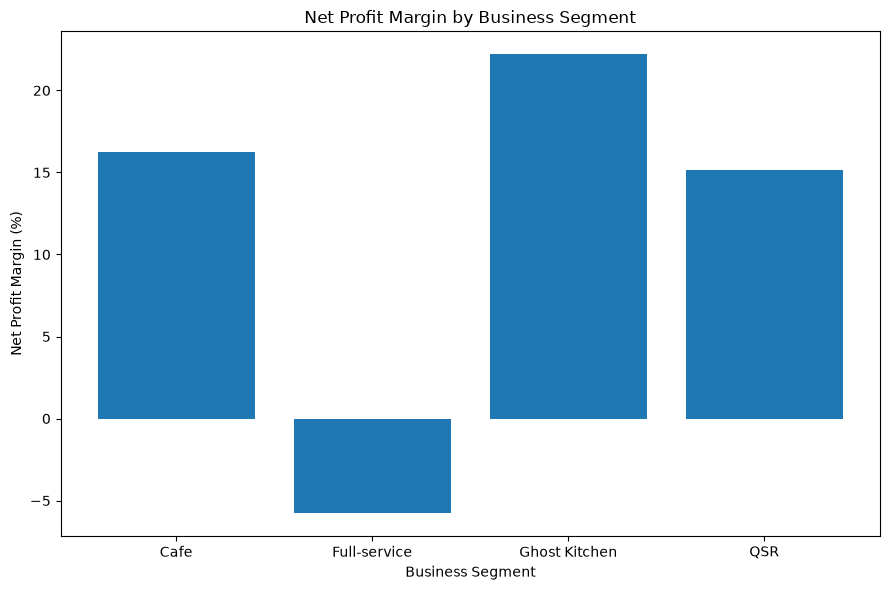

In [410]:
plt.figure(figsize=(9, 6))

plt.bar(
    segment_profitability["Segment"],
    segment_profitability["ProfitMargin"] * 100
)

plt.xlabel("Business Segment")
plt.ylabel("Net Profit Margin (%)")
plt.title("Net Profit Margin by Business Segment")

plt.tight_layout()
plt.show()

In [411]:
uber_segment = (
    analysis_df
    .groupby("Segment")
    .agg(
        Revenue=("UberEatsRevenue", "sum"),
        NetProfit=("UberEatsNetProfit", "sum"),
        Orders=("UberEatsOrders", "sum")
    )
    .reset_index()
)

uber_segment["Margin"] = (
    uber_segment["NetProfit"] /
    uber_segment["Revenue"]
)

uber_segment["ProfitPerOrder"] = (
    uber_segment["NetProfit"] /
    uber_segment["Orders"]
)

uber_segment

,Segment,Revenue,NetProfit,Orders,Margin,ProfitPerOrder
0,Cafe,9207149.63,560847.57,237970,0.060914,2.356799
1,Full-service,8157444.63,-1424668.75,214271,-0.174646,-6.648911
2,Ghost Kitchen,3627052.48,547773.19,94463,0.151024,5.798812
3,QSR,9824724.75,574536.07,253649,0.058479,2.265083


In [412]:
doordash_segment = (
    analysis_df
    .groupby("Segment")
    .agg(
        Revenue=("DoorDashRevenue", "sum"),
        NetProfit=("DoorDashNetProfit", "sum"),
        Orders=("DoorDashOrders", "sum")
    )
    .reset_index()
)

doordash_segment["Margin"] = (
    doordash_segment["NetProfit"] /
    doordash_segment["Revenue"]
)

doordash_segment["ProfitPerOrder"] = (
    doordash_segment["NetProfit"] /
    doordash_segment["Orders"]
)

doordash_segment

,Segment,Revenue,NetProfit,Orders,Margin,ProfitPerOrder
0,Cafe,5021433.74,307279.92,129729,0.061194,2.368629
1,Full-service,4415533.19,-770900.72,116083,-0.174588,-6.640944
2,Ghost Kitchen,1991765.31,301233.39,51844,0.151239,5.810381
3,QSR,5360648.71,313509.66,138479,0.058484,2.263951


In [413]:
self_delivery_summary = pd.DataFrame({
    "Metric": [
        "Revenue",
        "Orders",
        "Net Profit",
        "Profit Per Order",
        "Average Delivery Cost Per Order",
        "Average Self-Delivery Cost Ratio",
        "Average Self-Delivery ROI"
    ],
    "Value": [
        analysis_df["SelfDeliveryRevenue"].sum(),
        analysis_df["SelfDeliveryOrders"].sum(),
        analysis_df["SelfDeliveryNetProfit"].sum(),
        analysis_df["SelfDeliveryNetProfit"].sum() /
            analysis_df["SelfDeliveryOrders"].sum(),
        analysis_df["DeliveryCostPerOrder"].mean(),
        analysis_df["SelfDeliveryCostRatio"].mean(),
        analysis_df["SelfDeliveryROI"].mean()
    ]
})

self_delivery_summary

,Metric,Value
0,Revenue,1.584918e+07
1,Orders,4.112550e+05
2,Net Profit,3.628278e+06
3,Profit Per Order,8.822454e+00
4,Average Delivery Cost Per Order,3.119363e+00
5,Average Self-Delivery Cost Ratio,8.222943e-02
6,Average Self-Delivery ROI,3.974776e+00


In [414]:
self_delivery_segment = (
    analysis_df
    .groupby("Segment")
    .agg(
        Revenue=("SelfDeliveryRevenue", "sum"),
        NetProfit=("SelfDeliveryNetProfit", "sum"),
        Orders=("SelfDeliveryOrders", "sum"),
        AvgDeliveryCost=("DeliveryCostPerOrder", "mean"),
        AvgROI=("SelfDeliveryROI", "mean")
    )
    .reset_index()
)

self_delivery_segment["ProfitMargin"] = (
    self_delivery_segment["NetProfit"] /
    self_delivery_segment["Revenue"]
)

self_delivery_segment["ProfitPerOrder"] = (
    self_delivery_segment["NetProfit"] /
    self_delivery_segment["Orders"]
)

self_delivery_segment

,Segment,Revenue,NetProfit,Orders,AvgDeliveryCost,AvgROI,ProfitMargin,ProfitPerOrder
0,Cafe,4678308.38,1326729.78,121312,3.111667,4.786284,0.283592,10.936509
1,Full-service,4196124.42,171183.34,110157,3.139823,0.949993,0.040796,1.553994
2,Ghost Kitchen,1912226.36,707884.43,49449,3.210305,6.053723,0.370189,14.315445
3,QSR,5062517.13,1422480.89,130337,3.076483,4.985181,0.280983,10.913869


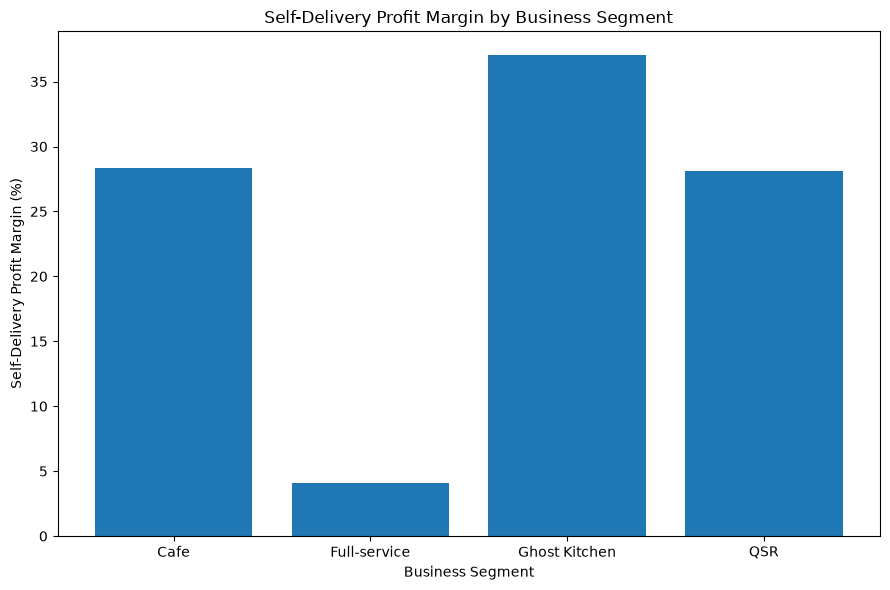

In [415]:
plt.figure(figsize=(9, 6))

plt.bar(
    self_delivery_segment["Segment"],
    self_delivery_segment["ProfitMargin"] * 100
)

plt.xlabel("Business Segment")
plt.ylabel("Self-Delivery Profit Margin (%)")
plt.title("Self-Delivery Profit Margin by Business Segment")

plt.tight_layout()
plt.show()

In [416]:
restaurant_profitability = (
    analysis_df
    .groupby(["RestaurantID", "RestaurantName", "CuisineType", "Segment"])
    .agg(
        Revenue=("TotalRevenue", "sum"),
        NetProfit=("TotalNetProfit", "sum"),
        Orders=("MonthlyOrders", "sum")
    )
    .reset_index()
)

restaurant_profitability["ProfitMargin"] = (
    restaurant_profitability["NetProfit"] /
    restaurant_profitability["Revenue"]
)

restaurant_profitability["ProfitPerOrder"] = (
    restaurant_profitability["NetProfit"] /
    restaurant_profitability["Orders"]
)

restaurant_profitability.head(10)

,RestaurantID,RestaurantName,CuisineType,Segment,Revenue,NetProfit,Orders,ProfitMargin,ProfitPerOrder
0,25001,Lotus Grill,Thai,QSR,19575.00,2713.68,580,0.138630,4.678759
1,25002,Top Pizza Bistro,Pizza,Full-service,48069.84,-1362.50,1092,-0.028344,-1.247711
2,25003,Red Bistro,Japanese,Cafe,37046.10,5014.78,885,0.135366,5.666418
3,25004,King Burgers Cafe,Burgers,Ghost Kitchen,56428.56,8587.35,1629,0.152181,5.271547
4,25005,Classic Burgers Bistro,Burgers,Ghost Kitchen,51351.75,11238.51,1305,0.218853,8.611885
5,25006,Lucky Pizza Cafe,Pizza,QSR,22576.03,5448.68,617,0.241348,8.830924
6,25007,Greek Cafe,Kebabs/Mediterranean,Cafe,24603.68,2911.87,734,0.118351,3.967125
7,25008,Golden Bistro,Japanese,Ghost Kitchen,47107.20,9506.39,1402,0.201803,6.780592
8,25009,Lucky Burgers Eatery,Burgers,Cafe,46972.24,7600.21,1036,0.161802,7.336110
9,25010,Lotus Bistro,Chinese,Cafe,48095.93,7205.28,1591,0.149811,4.528774


In [417]:
print("Top 10 restaurants by net profit:")

restaurant_profitability.sort_values(
    "NetProfit",
    ascending=False
).head(10)

Top 10 restaurants by net profit:


,RestaurantID,RestaurantName,CuisineType,Segment,Revenue,NetProfit,Orders,ProfitMargin,ProfitPerOrder
947,25948,King Pizza Eatery,Pizza,Cafe,95963.98,27368.36,2074,0.285194,13.195931
572,25573,Top Burgers Tavern,Burgers,Cafe,86382.94,21269.54,1946,0.246224,10.929877
933,25934,Urban Pizza Grill,Pizza,Cafe,85428.00,21101.73,1890,0.247012,11.164937
1523,26524,Lucky Pizza Bistro,Pizza,Cafe,82467.79,21091.11,1801,0.255750,11.710777
574,25575,Red Cafe,Japanese,Ghost Kitchen,73449.75,20911.68,1595,0.284707,13.110771
417,25418,Top Burgers Eatery,Burgers,Cafe,84025.89,20842.89,1941,0.248053,10.738223
597,25598,Top Burgers Diner,Burgers,Cafe,86838.25,20828.26,2131,0.239851,9.773937
1573,26574,Urban Pizza Tavern,Pizza,Cafe,93352.17,20827.71,2103,0.223109,9.903809
297,25298,Classic Pizza Eatery,Pizza,QSR,89660.30,20217.63,1915,0.225491,10.557509
355,25356,Golden Bistro,Chinese,Ghost Kitchen,63181.84,19741.76,1576,0.312459,12.526497


In [418]:
print("Bottom 10 restaurants by net profit:")

restaurant_profitability.sort_values(
    "NetProfit",
    ascending=True
).head(10)

Bottom 10 restaurants by net profit:


,RestaurantID,RestaurantName,CuisineType,Segment,Revenue,NetProfit,Orders,ProfitMargin,ProfitPerOrder
338,25339,Ottoman Diner,Kebabs/Mediterranean,Full-service,81510.12,-10192.83,1762,-0.125050,-5.784807
392,25393,Tandoori Kitchen,Indian,Full-service,73812.75,-9974.52,1725,-0.135133,-5.782330
836,25837,Spice Diner,Indian,Full-service,83654.68,-9840.65,1817,-0.117634,-5.415878
841,25842,Lotus Tavern,Thai,Full-service,73264.00,-9224.14,1900,-0.125903,-4.854811
469,25470,Greek House,Kebabs/Mediterranean,Full-service,73497.60,-9202.01,1920,-0.125202,-4.792714
691,25692,Greek Grill,Kebabs/Mediterranean,Full-service,67380.56,-9024.43,1742,-0.133932,-5.180499
1034,26035,Top Chicken Dishes Corner,Chicken Dishes,Full-service,82752.40,-8962.15,1772,-0.108301,-5.057647
446,25447,Souvlaki Tavern,Kebabs/Mediterranean,Full-service,63752.04,-8948.12,1683,-0.140358,-5.316768
540,25541,Bombay House,Indian,Full-service,84393.20,-8905.84,1880,-0.105528,-4.737149
1333,26334,Ottoman Bistro,Kebabs/Mediterranean,Full-service,48478.68,-8562.72,1299,-0.176629,-6.591778


In [419]:
negative_profit = restaurant_profitability[
    restaurant_profitability["NetProfit"] < 0
]

print("Number of loss-making restaurants:", len(negative_profit))

negative_profit.sort_values(
    "NetProfit"
).head(10)

Number of loss-making restaurants: 408


,RestaurantID,RestaurantName,CuisineType,Segment,Revenue,NetProfit,Orders,ProfitMargin,ProfitPerOrder
338,25339,Ottoman Diner,Kebabs/Mediterranean,Full-service,81510.12,-10192.83,1762,-0.125050,-5.784807
392,25393,Tandoori Kitchen,Indian,Full-service,73812.75,-9974.52,1725,-0.135133,-5.782330
836,25837,Spice Diner,Indian,Full-service,83654.68,-9840.65,1817,-0.117634,-5.415878
841,25842,Lotus Tavern,Thai,Full-service,73264.00,-9224.14,1900,-0.125903,-4.854811
469,25470,Greek House,Kebabs/Mediterranean,Full-service,73497.60,-9202.01,1920,-0.125202,-4.792714
691,25692,Greek Grill,Kebabs/Mediterranean,Full-service,67380.56,-9024.43,1742,-0.133932,-5.180499
1034,26035,Top Chicken Dishes Corner,Chicken Dishes,Full-service,82752.40,-8962.15,1772,-0.108301,-5.057647
446,25447,Souvlaki Tavern,Kebabs/Mediterranean,Full-service,63752.04,-8948.12,1683,-0.140358,-5.316768
540,25541,Bombay House,Indian,Full-service,84393.20,-8905.84,1880,-0.105528,-4.737149
1333,26334,Ottoman Bistro,Kebabs/Mediterranean,Full-service,48478.68,-8562.72,1299,-0.176629,-6.591778


In [420]:
restaurant_profitability["ProfitStatus"] = (
    restaurant_profitability["NetProfit"]
    .apply(lambda x: "Loss" if x < 0 else "Profit")
)

profit_status_summary = (
    restaurant_profitability
    .groupby("ProfitStatus")
    .agg(
        Restaurants=("RestaurantID", "count"),
        Revenue=("Revenue", "sum"),
        NetProfit=("NetProfit", "sum"),
        Orders=("Orders", "sum"),
        AvgProfitMargin=("ProfitMargin", "mean"),
        AvgProfitPerOrder=("ProfitPerOrder", "mean")
    )
    .reset_index()
)

profit_status_summary

,ProfitStatus,Restaurants,Revenue,NetProfit,Orders,AvgProfitMargin,AvgProfitPerOrder
0,Loss,408,20257023.6,-1349691.34,532244,-0.067780,-2.564774
1,Profit,1288,57482283.2,9215997.47,1486890,0.159017,6.166369


In [421]:
loss_by_segment = (
    negative_profit
    .groupby("Segment")
    .agg(
        LossMakingRestaurants=("RestaurantID", "count"),
        Revenue=("Revenue", "sum"),
        NetProfit=("NetProfit", "sum"),
        Orders=("Orders", "sum")
    )
    .reset_index()
)

loss_by_segment["ProfitMargin"] = (
    loss_by_segment["NetProfit"] /
    loss_by_segment["Revenue"]
)

loss_by_segment


,Segment,LossMakingRestaurants,Revenue,NetProfit,Orders,ProfitMargin
0,Full-service,408,20257023.6,-1349691.34,532244,-0.066628


In [422]:
loss_by_cuisine = (
    negative_profit
    .groupby("CuisineType")
    .agg(
        LossMakingRestaurants=("RestaurantID", "count"),
        Revenue=("Revenue", "sum"),
        NetProfit=("NetProfit", "sum"),
        Orders=("Orders", "sum")
    )
    .reset_index()
)

loss_by_cuisine["ProfitMargin"] = (
    loss_by_cuisine["NetProfit"] /
    loss_by_cuisine["Revenue"]
)

loss_by_cuisine.sort_values(
    "NetProfit"
)

,CuisineType,LossMakingRestaurants,Revenue,NetProfit,Orders,ProfitMargin
3,Indian,83,3853616.30,-277941.03,101388,-0.072125
0,Burgers,81,4342479.58,-228800.69,113191,-0.052689
5,Kebabs/Mediterranean,47,2186839.81,-206862.40,58092,-0.094594
2,Chinese,50,2593358.63,-165028.48,68414,-0.063635
1,Chicken Dishes,49,2454085.37,-162360.20,63008,-0.066159
7,Thai,28,1315792.04,-116019.24,35175,-0.088174
4,Japanese,26,1149399.89,-105104.50,31158,-0.091443
6,Pizza,44,2361451.98,-87574.80,61818,-0.037085


Analyze the operational and financial characteristics of loss-making restaurants using revenue, order volume, profit margin, and profit per order.

In [423]:
# Find all DataFrames currently available in the notebook
for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        print(f"\n{name}")
        print("Shape:", obj.shape)
        print("Columns:", obj.columns.tolist())


_
Shape: (8, 6)
Columns: ['CuisineType', 'LossMakingRestaurants', 'Revenue', 'NetProfit', 'Orders', 'ProfitMargin']

__
Shape: (1, 6)
Columns: ['Segment', 'LossMakingRestaurants', 'Revenue', 'NetProfit', 'Orders', 'ProfitMargin']

___
Shape: (2, 7)
Columns: ['ProfitStatus', 'Restaurants', 'Revenue', 'NetProfit', 'Orders', 'AvgProfitMargin', 'AvgProfitPerOrder']

df
Shape: (1696, 57)
Columns: ['CuisineType', 'RestaurantID', 'RestaurantName', 'Segment', 'Subregion', 'GrowthFactor', 'AOV', 'MonthlyOrders', 'InStoreOrders', 'InStoreRevenue', 'UberEatsOrders', 'DoorDashOrders', 'SelfDeliveryOrders', 'UberEatsRevenue', 'DoorDashRevenue', 'SelfDeliveryRevenue', 'COGSRate', 'OPEXRate', 'CommissionRate', 'DeliveryRadiusKM', 'DeliveryCostPerOrder', 'SD_DeliveryTotalCost', 'InStoreNetProfit', 'UberEatsNetProfit', 'DoorDashNetProfit', 'SelfDeliveryNetProfit', 'InStoreShare', 'UE_share', 'DD_share', 'SD_share', 'CalculatedTotalOrders', 'OrderDifference', 'ExpectedInStoreRevenue', 'ExpectedUberEats

In [424]:
# Check the actual columns available in the dataset
print(negative_profit.columns.tolist())

['RestaurantID', 'RestaurantName', 'CuisineType', 'Segment', 'Revenue', 'NetProfit', 'Orders', 'ProfitMargin', 'ProfitPerOrder']


In [425]:
loss_analysis = negative_profit[
    [
        "RestaurantID",
        "RestaurantName",
        "CuisineType",
        "Segment",
        "Revenue",
        "Orders",
        "NetProfit",
        "ProfitMargin",
        "ProfitPerOrder"
    ]
].copy()

loss_analysis["RevenuePerOrder"] = (
    loss_analysis["Revenue"] /
    loss_analysis["Orders"]
)

loss_analysis.head(10)

,RestaurantID,RestaurantName,CuisineType,Segment,Revenue,Orders,NetProfit,ProfitMargin,ProfitPerOrder,RevenuePerOrder
1,25002,Top Pizza Bistro,Pizza,Full-service,48069.84,1092,-1362.50,-0.028344,-1.247711,44.02
12,25013,Tandoori House,Indian,Full-service,61299.00,1668,-3194.18,-0.052108,-1.914976,36.75
21,25022,Lucky Pizza Diner,Pizza,Full-service,78544.24,1706,-4837.90,-0.061595,-2.835815,46.04
22,25023,Red Grill,Chinese,Full-service,33748.75,931,-4218.04,-0.124984,-4.530655,36.25
24,25025,Top Pizza Grill,Pizza,Full-service,61605.60,1930,-5122.87,-0.083156,-2.654337,31.92
25,25026,Lucky Chicken Dishes Eatery,Chicken Dishes,Full-service,71621.04,1959,-1842.17,-0.025721,-0.940362,36.56
32,25033,Spice Diner,Indian,Full-service,21599.10,618,-1027.10,-0.047553,-1.661974,34.95
33,25034,Golden Bistro,Chinese,Full-service,77701.12,2048,-1026.46,-0.013210,-0.501201,37.94
36,25037,Curry Cafe,Indian,Full-service,30306.60,745,-1797.92,-0.059324,-2.413315,40.68
49,25050,Golden Kitchen,Chinese,Full-service,61745.31,1551,-2537.79,-0.041101,-1.636228,39.81


In [426]:
loss_summary = pd.DataFrame({
    "Metric": [
        "Loss-Making Restaurants",
        "Total Revenue",
        "Total Orders",
        "Total Net Loss",
        "Average Profit Margin",
        "Average Profit Per Order",
        "Average Revenue Per Order"
    ],
    "Value": [
        len(loss_analysis),
        loss_analysis["Revenue"].sum(),
        loss_analysis["Orders"].sum(),
        loss_analysis["NetProfit"].sum(),
        loss_analysis["ProfitMargin"].mean(),
        loss_analysis["ProfitPerOrder"].mean(),
        loss_analysis["RevenuePerOrder"].mean()
    ]
})

loss_summary

,Metric,Value
0,Loss-Making Restaurants,4.080000e+02
1,Total Revenue,2.025702e+07
2,Total Orders,5.322440e+05
3,Total Net Loss,-1.349691e+06
4,Average Profit Margin,-6.778008e-02
5,Average Profit Per Order,-2.564774e+00
6,Average Revenue Per Order,3.808738e+01


In [427]:
loss_segment_summary = (
    loss_analysis
    .groupby("Segment")
    .agg(
        Restaurants=("RestaurantID", "count"),
        Revenue=("Revenue", "sum"),
        Orders=("Orders", "sum"),
        NetLoss=("NetProfit", "sum")
    )
    .reset_index()
)

loss_segment_summary["ProfitMargin"] = (
    loss_segment_summary["NetLoss"] /
    loss_segment_summary["Revenue"]
)

loss_segment_summary

,Segment,Restaurants,Revenue,Orders,NetLoss,ProfitMargin
0,Full-service,408,20257023.6,532244,-1349691.34,-0.066628


Analyze loss-making restaurants by cuisine to identify which cuisine types contribute most to the overall net loss.

In [428]:
loss_by_cuisine = (
    loss_analysis
    .groupby("CuisineType")
    .agg(
        Restaurants=("RestaurantID", "count"),
        Revenue=("Revenue", "sum"),
        Orders=("Orders", "sum"),
        NetLoss=("NetProfit", "sum")
    )
    .reset_index()
)

loss_by_cuisine["ProfitMargin"] = (
    loss_by_cuisine["NetLoss"] /
    loss_by_cuisine["Revenue"]
)

loss_by_cuisine = loss_by_cuisine.sort_values(
    "NetLoss",
    ascending=True
)

loss_by_cuisine

,CuisineType,Restaurants,Revenue,Orders,NetLoss,ProfitMargin
3,Indian,83,3853616.30,101388,-277941.03,-0.072125
0,Burgers,81,4342479.58,113191,-228800.69,-0.052689
5,Kebabs/Mediterranean,47,2186839.81,58092,-206862.40,-0.094594
2,Chinese,50,2593358.63,68414,-165028.48,-0.063635
1,Chicken Dishes,49,2454085.37,63008,-162360.20,-0.066159
7,Thai,28,1315792.04,35175,-116019.24,-0.088174
4,Japanese,26,1149399.89,31158,-105104.50,-0.091443
6,Pizza,44,2361451.98,61818,-87574.80,-0.037085


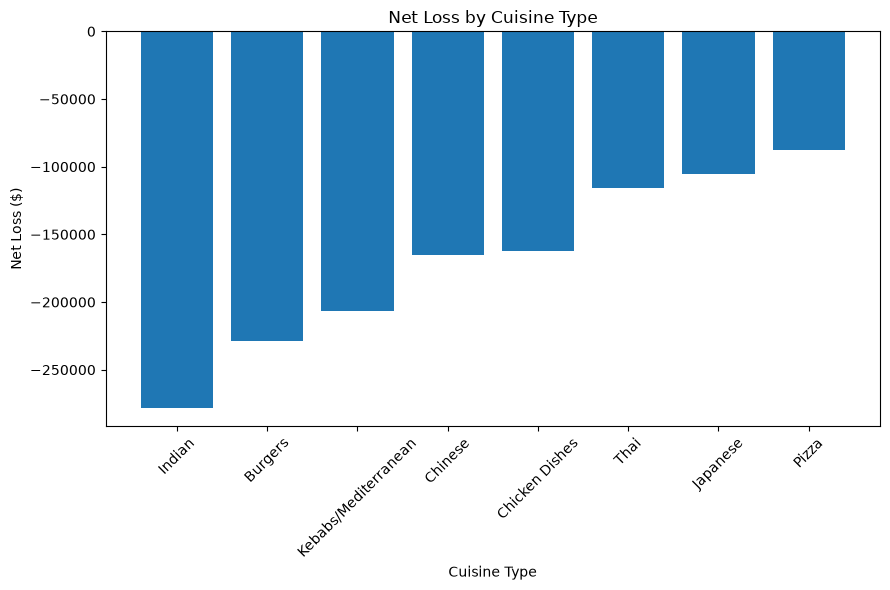

In [429]:
plt.figure(figsize=(9, 6))

plt.bar(
    loss_by_cuisine["CuisineType"],
    loss_by_cuisine["NetLoss"]
)

plt.title("Net Loss by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Net Loss ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Identify the individual restaurants with the largest net losses and examine their revenue, order volume, profit margin, and profit per order.

In [430]:
top_loss_restaurants = (
    loss_analysis
    .sort_values("NetProfit", ascending=True)
    .head(10)
)

top_loss_restaurants

,RestaurantID,RestaurantName,CuisineType,Segment,Revenue,Orders,NetProfit,ProfitMargin,ProfitPerOrder,RevenuePerOrder
338,25339,Ottoman Diner,Kebabs/Mediterranean,Full-service,81510.12,1762,-10192.83,-0.125050,-5.784807,46.26
392,25393,Tandoori Kitchen,Indian,Full-service,73812.75,1725,-9974.52,-0.135133,-5.782330,42.79
836,25837,Spice Diner,Indian,Full-service,83654.68,1817,-9840.65,-0.117634,-5.415878,46.04
841,25842,Lotus Tavern,Thai,Full-service,73264.00,1900,-9224.14,-0.125903,-4.854811,38.56
469,25470,Greek House,Kebabs/Mediterranean,Full-service,73497.60,1920,-9202.01,-0.125202,-4.792714,38.28
691,25692,Greek Grill,Kebabs/Mediterranean,Full-service,67380.56,1742,-9024.43,-0.133932,-5.180499,38.68
1034,26035,Top Chicken Dishes Corner,Chicken Dishes,Full-service,82752.40,1772,-8962.15,-0.108301,-5.057647,46.70
446,25447,Souvlaki Tavern,Kebabs/Mediterranean,Full-service,63752.04,1683,-8948.12,-0.140358,-5.316768,37.88
540,25541,Bombay House,Indian,Full-service,84393.20,1880,-8905.84,-0.105528,-4.737149,44.89
1333,26334,Ottoman Bistro,Kebabs/Mediterranean,Full-service,48478.68,1299,-8562.72,-0.176629,-6.591778,37.32


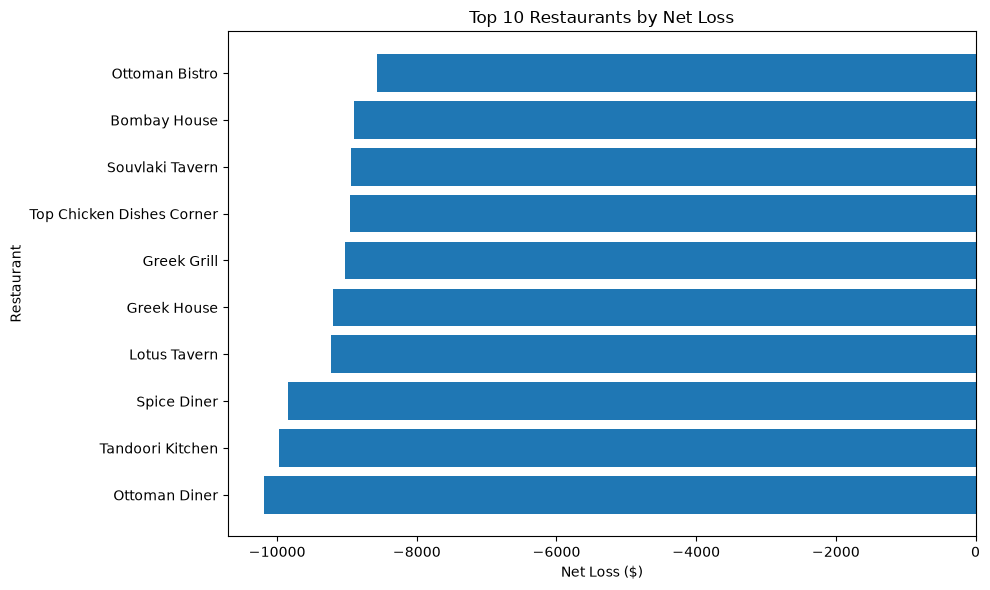

In [431]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_loss_restaurants["RestaurantName"],
    top_loss_restaurants["NetProfit"]
)

plt.title("Top 10 Restaurants by Net Loss")
plt.xlabel("Net Loss ($)")
plt.ylabel("Restaurant")

plt.tight_layout()
plt.show()

In [432]:
top_loss_restaurants[
    [
        "RestaurantName",
        "CuisineType",
        "Segment",
        "Revenue",
        "Orders",
        "NetProfit",
        "ProfitMargin",
        "ProfitPerOrder"
    ]
]

,RestaurantName,CuisineType,Segment,Revenue,Orders,NetProfit,ProfitMargin,ProfitPerOrder
338,Ottoman Diner,Kebabs/Mediterranean,Full-service,81510.12,1762,-10192.83,-0.125050,-5.784807
392,Tandoori Kitchen,Indian,Full-service,73812.75,1725,-9974.52,-0.135133,-5.782330
836,Spice Diner,Indian,Full-service,83654.68,1817,-9840.65,-0.117634,-5.415878
841,Lotus Tavern,Thai,Full-service,73264.00,1900,-9224.14,-0.125903,-4.854811
469,Greek House,Kebabs/Mediterranean,Full-service,73497.60,1920,-9202.01,-0.125202,-4.792714
691,Greek Grill,Kebabs/Mediterranean,Full-service,67380.56,1742,-9024.43,-0.133932,-5.180499
1034,Top Chicken Dishes Corner,Chicken Dishes,Full-service,82752.40,1772,-8962.15,-0.108301,-5.057647
446,Souvlaki Tavern,Kebabs/Mediterranean,Full-service,63752.04,1683,-8948.12,-0.140358,-5.316768
540,Bombay House,Indian,Full-service,84393.20,1880,-8905.84,-0.105528,-4.737149
1333,Ottoman Bistro,Kebabs/Mediterranean,Full-service,48478.68,1299,-8562.72,-0.176629,-6.591778


In [433]:
loss_drivers = loss_analysis[
    [
        "RestaurantID",
        "RestaurantName",
        "CuisineType",
        "Segment",
        "Revenue",
        "Orders",
        "NetProfit",
        "ProfitMargin",
        "ProfitPerOrder",
        "RevenuePerOrder"
    ]
].copy()

loss_drivers["ProfitPerOrder"] = (
    loss_drivers["NetProfit"] / loss_drivers["Orders"]
)

loss_drivers.head(10)


,RestaurantID,RestaurantName,CuisineType,Segment,Revenue,Orders,NetProfit,ProfitMargin,ProfitPerOrder,RevenuePerOrder
1,25002,Top Pizza Bistro,Pizza,Full-service,48069.84,1092,-1362.50,-0.028344,-1.247711,44.02
12,25013,Tandoori House,Indian,Full-service,61299.00,1668,-3194.18,-0.052108,-1.914976,36.75
21,25022,Lucky Pizza Diner,Pizza,Full-service,78544.24,1706,-4837.90,-0.061595,-2.835815,46.04
22,25023,Red Grill,Chinese,Full-service,33748.75,931,-4218.04,-0.124984,-4.530655,36.25
24,25025,Top Pizza Grill,Pizza,Full-service,61605.60,1930,-5122.87,-0.083156,-2.654337,31.92
25,25026,Lucky Chicken Dishes Eatery,Chicken Dishes,Full-service,71621.04,1959,-1842.17,-0.025721,-0.940362,36.56
32,25033,Spice Diner,Indian,Full-service,21599.10,618,-1027.10,-0.047553,-1.661974,34.95
33,25034,Golden Bistro,Chinese,Full-service,77701.12,2048,-1026.46,-0.013210,-0.501201,37.94
36,25037,Curry Cafe,Indian,Full-service,30306.60,745,-1797.92,-0.059324,-2.413315,40.68
49,25050,Golden Kitchen,Chinese,Full-service,61745.31,1551,-2537.79,-0.041101,-1.636228,39.81


In [434]:
loss_drivers[
    [
        "Revenue",
        "Orders",
        "NetProfit",
        "ProfitMargin",
        "ProfitPerOrder",
        "RevenuePerOrder"
    ]
].corr()

,Revenue,Orders,NetProfit,ProfitMargin,ProfitPerOrder,RevenuePerOrder
Revenue,1.000000,0.943730,-0.467320,0.090662,0.029179,0.294922
Orders,0.943730,1.000000,-0.467889,0.056591,0.062636,-0.018832
NetProfit,-0.467320,-0.467889,1.000000,0.781273,0.801849,-0.072506
ProfitMargin,0.090662,0.056591,0.781273,1.000000,0.970800,0.111120
ProfitPerOrder,0.029179,0.062636,0.801849,0.970800,1.000000,-0.103847
RevenuePerOrder,0.294922,-0.018832,-0.072506,0.111120,-0.103847,1.000000


In [435]:
loss_drivers[
    [
        "RestaurantName",
        "Revenue",
        "Orders",
        "RevenuePerOrder",
        "NetProfit",
        "ProfitMargin",
        "ProfitPerOrder"
    ]
].sort_values("NetProfit").head(10)

,RestaurantName,Revenue,Orders,RevenuePerOrder,NetProfit,ProfitMargin,ProfitPerOrder
338,Ottoman Diner,81510.12,1762,46.26,-10192.83,-0.125050,-5.784807
392,Tandoori Kitchen,73812.75,1725,42.79,-9974.52,-0.135133,-5.782330
836,Spice Diner,83654.68,1817,46.04,-9840.65,-0.117634,-5.415878
841,Lotus Tavern,73264.00,1900,38.56,-9224.14,-0.125903,-4.854811
469,Greek House,73497.60,1920,38.28,-9202.01,-0.125202,-4.792714
691,Greek Grill,67380.56,1742,38.68,-9024.43,-0.133932,-5.180499
1034,Top Chicken Dishes Corner,82752.40,1772,46.70,-8962.15,-0.108301,-5.057647
446,Souvlaki Tavern,63752.04,1683,37.88,-8948.12,-0.140358,-5.316768
540,Bombay House,84393.20,1880,44.89,-8905.84,-0.105528,-4.737149
1333,Ottoman Bistro,48478.68,1299,37.32,-8562.72,-0.176629,-6.591778


In [436]:
profitability_comparison = pd.DataFrame({
    "Metric": [
        "Restaurants",
        "Revenue",
        "Orders",
        "Net Profit",
        "Profit Margin",
        "Profit Per Order",
        "Revenue Per Order"
    ],
    "Loss-Making": [
        len(negative_profit),
        negative_profit["Revenue"].sum(),
        negative_profit["Orders"].sum(),
        negative_profit["NetProfit"].sum(),
        negative_profit["NetProfit"].sum() / negative_profit["Revenue"].sum(),
        negative_profit["NetProfit"].sum() / negative_profit["Orders"].sum(),
        negative_profit["Revenue"].sum() / negative_profit["Orders"].sum()
    ],
    "Profitable": [
        len(restaurant_profitability[restaurant_profitability["NetProfit"] > 0]),
        restaurant_profitability.loc[
            restaurant_profitability["NetProfit"] > 0, "Revenue"
        ].sum(),
        restaurant_profitability.loc[
            restaurant_profitability["NetProfit"] > 0, "Orders"
        ].sum(),
        restaurant_profitability.loc[
            restaurant_profitability["NetProfit"] > 0, "NetProfit"
        ].sum(),
        restaurant_profitability.loc[
            restaurant_profitability["NetProfit"] > 0, "NetProfit"
        ].sum()
        / restaurant_profitability.loc[
            restaurant_profitability["NetProfit"] > 0, "Revenue"
        ].sum(),
        restaurant_profitability.loc[
            restaurant_profitability["NetProfit"] > 0, "NetProfit"
        ].sum()
        / restaurant_profitability.loc[
            restaurant_profitability["NetProfit"] > 0, "Orders"
        ].sum(),
        restaurant_profitability.loc[
            restaurant_profitability["NetProfit"] > 0, "Revenue"
        ].sum()
        / restaurant_profitability.loc[
            restaurant_profitability["NetProfit"] > 0, "Orders"
        ].sum()
    ]
})

profitability_comparison

,Metric,Loss-Making,Profitable
0,Restaurants,4.080000e+02,1.288000e+03
1,Revenue,2.025702e+07,5.748228e+07
2,Orders,5.322440e+05,1.486890e+06
3,Net Profit,-1.349691e+06,9.215997e+06
4,Profit Margin,-6.662831e-02,1.603276e-01
5,Profit Per Order,-2.535851e+00,6.198170e+00
6,Revenue Per Order,3.805966e+01,3.865941e+01


<Figure size 900x600 with 0 Axes>

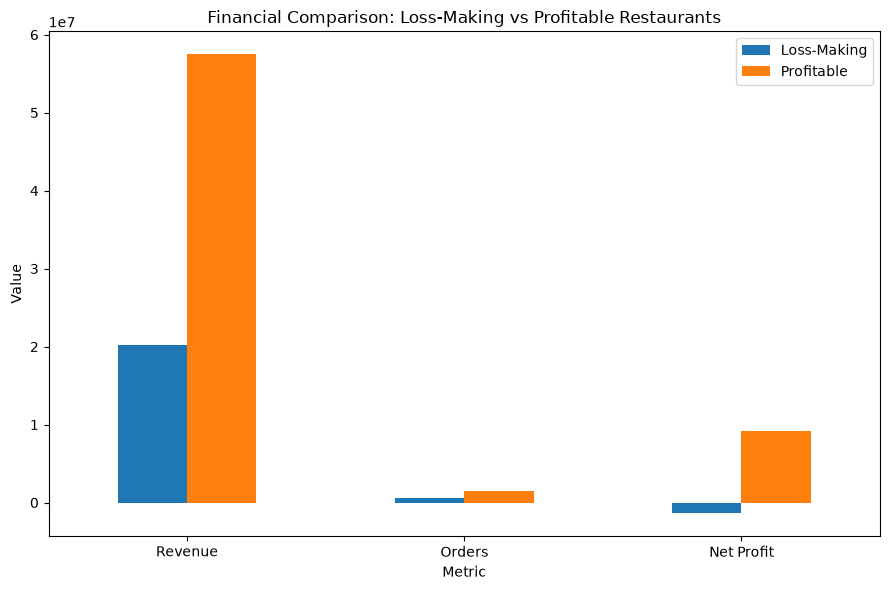

In [437]:
plt.figure(figsize=(9, 6))

profitability_comparison.set_index("Metric")[
    ["Loss-Making", "Profitable"]
].loc[
    ["Revenue", "Orders", "Net Profit"]
].plot(kind="bar", figsize=(9, 6))

plt.title("Financial Comparison: Loss-Making vs Profitable Restaurants")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

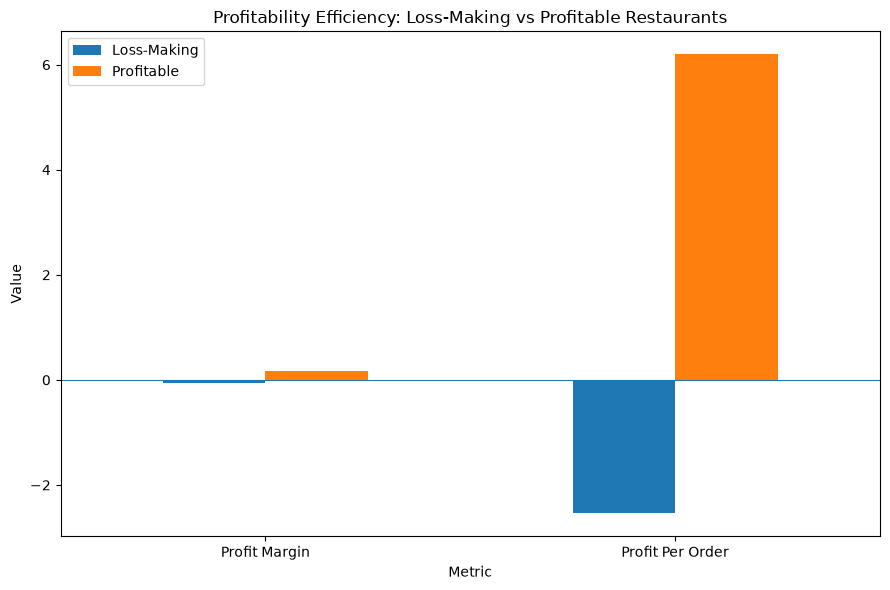

In [438]:
profitability_comparison.set_index("Metric")[
    ["Loss-Making", "Profitable"]
].loc[
    ["Profit Margin", "Profit Per Order"]
].plot(kind="bar", figsize=(9, 6))

plt.title("Profitability Efficiency: Loss-Making vs Profitable Restaurants")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.axhline(0, linewidth=0.8)
plt.tight_layout()
plt.show()

## Key Finding: Profitability Comparison

The analysis identifies a substantial difference between profitable and loss-making restaurants.

Loss-making restaurants generated significant revenue and order volume but still recorded negative net profit, indicating that sales volume alone does not guarantee profitability.

The loss-making group recorded a negative average profit margin and negative profit per order, while profitable restaurants maintained positive values for both metrics.

This indicates that improving the economics of individual orders and maintaining healthy profit margins should be a key focus when addressing underperforming restaurants.

# Business Recommendations

Based on the profitability, channel, segment, cuisine, and restaurant-level analysis, the following recommendations can be made:

### 1. Prioritize Underperforming Full-Service Restaurants
All 408 identified loss-making restaurants belong to the Full-service segment, with a combined net loss of approximately $13.50M. These restaurants should be reviewed individually to identify the operational factors contributing to negative profitability.

### 2. Focus on Profit Per Order
Loss-making restaurants have an average profit per order of approximately -$2.54, compared with approximately $6.20 for profitable restaurants. Management should focus on improving the economics of each order rather than relying only on increasing order volume.

### 3. Investigate High-Revenue Loss-Making Restaurants
Several loss-making restaurants generate substantial revenue and orders but still report negative net profit. These restaurants require closer examination because increasing sales without improving margins may increase overall losses.

### 4. Review Low-Margin Cuisines
Indian, Burgers, and Kebab/Mediterranean restaurants account for substantial portions of the identified cuisine-level losses. These categories should be investigated for pricing, operating efficiency, and cost-related factors.

### 5. Monitor Restaurant-Level Profitability
Restaurant-level metrics such as Net Profit, Profit Margin, Profit Per Order, Revenue Per Order, and Order Volume should be monitored regularly to identify deteriorating performance early.

### 6. Use Channel-Level Analysis for Cost Control
Delivery channels such as Uber Eats and DoorDash show substantially lower profit margins than In-Store and Self-Delivery. Channel economics should therefore be evaluated alongside revenue when making channel-management decisions.

### 7. Avoid Optimizing for Revenue Alone
The analysis demonstrates that higher revenue and order volume do not necessarily translate into higher profitability. Business decisions should consider both revenue generation and the profitability generated from each order.

# Conclusion

This analysis examined restaurant profitability across channels, business segments, cuisine types, and individual restaurants.

The analysis found that profitability varies substantially across business segments and channels. A total of 408 restaurants were identified as loss-making, with the Full-service segment accounting for all identified loss-making restaurants in this dataset.

The comparison between profitable and loss-making restaurants also shows that revenue and order volume alone are insufficient indicators of business performance. Profit margin and profit per order provide important additional measures for evaluating restaurant-level profitability.

Overall, the analysis provides a data-driven framework for identifying underperforming restaurants, understanding profitability patterns, and supporting targeted operational and financial reviews.